# NeuroScan AI v3.0 — Brain MRI Tumour Segmentation & Classification

**A rebuilt, auditable replacement for `Neuroscan_V2.ipynb`.**

Every defect found in the v2 audit is fixed here, and the fixes that matter are
enforced by assertions that run as the notebook executes — so a regression stops
the run instead of printing a confident wrong number.

| # | v2 problem | v3 fix | Where |
|---|---|---|---|
| F1 | Baseline kept a frozen backbone while the ROI model was fine-tuned, so the comparison was confounded | Two arms, identical architecture / seed / schedule / monitor; the **only** difference is the input crop. Paired McNemar test on the result | Phase 3, Evaluation |
| F2 | Trained the segmenter on CLAHE+Otsu proxy masks although BRISC2025 ships expert masks | Uses `segmentation_task/*/masks` directly; proxies are opt-in via `cfg.allow_proxy_masks` and never silent | Discovery, Phase 1 |
| F3 | Grad-CAM raised `list index out of range` on a frozen backbone | Input tensor requires grad; `register_full_backward_hook`; the class raises if nothing was captured | Grad-CAM |
| F4 | Phase 4 demo called `generate_gradcam` before it was defined | Grad-CAM is defined before its first use, and the notebook runs strictly top to bottom | ordering |
| F5 | Mis-indented `break` produced 1 of 4 explanations while reporting 4 | Correct loop nesting, plus `assert len(XAI_RESULTS) == len(CLASS_NAMES)` | Explainability |
| F6 | `no_tumor` reports degraded to risk UNKNOWN with no interpretation | Keys normalised with `re.sub(r"[^a-z]", "", ...)`; dictionary coverage asserted at import | Report |
| F7 | `param_group['max_norm']` did nothing — there was no gradient clipping | `clip_grad_norm_` after `scaler.unscale_`, before `optimizer.step()` | Engine |
| F8 | PDF hard-coded 97.81% accuracy and named the wrong dataset | Every figure is read from live metric objects | Report |
| F9 | Early stopping watched `val_loss`, checkpointing watched `val_accuracy` — memory and disk could disagree | One `Monitor` drives both, on one metric per task | Engine |
| F10 | Dashboard, audit and summary cells were each defined twice; `run_clinical_analysis` was shadowed | Each function defined exactly once | throughout |
| F11 | Phase 5 report still described TensorFlow, `.keras` files and `load_model` | No stale documentation; the README is generated from the run | Release |
| F12 | Release README described a diabetic-retinopathy project and used dummy metrics | README generated from live results, correct project | Release |
| F13 | Markdown contained un-evaluated `{{ acc*100:.2f }}` placeholders | Numbers are printed by code, never templated into markdown | throughout |
| F14 | Dedup reported 0 removed while the array shrank by 38 | Counters are exhaustive and reconciled by assertion | Integrity |
| F15 | Summary described Stage B settings as if they were the shipped model | Summary reads the deployed arm's actual stage log | Release |
| F16 | Artefact list probed `end_to_end_result.png`, which nothing wrote | Files register themselves as they are written | throughout |
| F17 | Grad-CAM ran on full images for a model trained on ROI crops | Heat maps are always computed on the model's own input domain | Explainability |
| F18 | Reported "top-20 layers" — not a portable unit | Reports trainable parameter counts alongside module counts | Phase 3 |

### Additional changes beyond the defect list

- The **official BRISC2025 test folder** is now the held-out set. v2 never used it: it re-split the training directory, so its reported accuracy was measured on the training distribution.
- `Dataset`/`DataLoader` with parallel workers replaces infinite generators driven by a step count.
- ROI boxes are computed **once**, batched, and cached — not re-segmented per sample per epoch.
- Attention gates use the canonical coarse-gating formulation instead of a down-then-up cycle at the same resolution.
- The classifier head is `Linear → BatchNorm → ReLU → Dropout`; v2 normalised after the ReLU.
- TTA is a fixed deterministic bank, so two runs on one image agree.
- Ensemble weights are fitted on validation rather than hard-coded at 50/30/20.
- Dice is computed per sample then averaged, and empty masks score correctly instead of producing NaN.

> **Run order:** top to bottom, once. Set a GPU runtime.
> **Not a medical device.** Research use only.

## 1 · Configuration

Every hyperparameter in the notebook lives here. Nothing downstream hard-codes a value, so an ablation is a one-line edit.

In [1]:
# ═════════════════════════════════════════════════════════════════════════════
#  CONFIG — single source of truth. Nothing below this cell hard-codes a value.
# ═════════════════════════════════════════════════════════════════════════════
from dataclasses import dataclass, field, asdict
from typing import Tuple, Optional


@dataclass
class CFG:
    # ── identity ────────────────────────────────────────────────────────────
    project: str = "NeuroScan AI v3.0"
    dataset_name: str = "BRISC2025 (briscdataset/brisc2025)"

    # ── reproducibility ─────────────────────────────────────────────────────
    seed: int = 42
    deterministic: bool = True

    # ── data ────────────────────────────────────────────────────────────────
    img_size: int = 224
    class_names: Tuple[str, ...] = ("glioma", "meningioma", "no_tumor", "pituitary")
    tumour_classes: Tuple[str, ...] = ("glioma", "meningioma", "pituitary")
    val_fraction: float = 0.15          # carved out of the OFFICIAL train split
    use_official_test: bool = True      # never re-split the official test folder
    allow_proxy_masks: bool = False     # proxy masks are opt-in, never silent

    # ── segmenter (Attention U-Net) ─────────────────────────────────────────
    seg_filters: Tuple[int, ...] = (32, 64, 128, 256, 512)
    seg_batch: int = 8
    seg_epochs: int = 60
    seg_lr: float = 3e-4
    seg_patience: int = 12
    seg_monitor: str = "val_dice"       # ONE criterion: stop + checkpoint agree
    seg_bce_weight: float = 0.5
    seg_dice_weight: float = 0.5

    # ── classifier (EfficientNet-B0) ────────────────────────────────────────
    clf_batch: int = 16
    clf_monitor: str = "val_macro_f1"   # ONE criterion: stop + checkpoint agree
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05
    head_hidden: int = 256
    head_dropout: Tuple[float, float] = (0.40, 0.30)

    # Progressive unfreeze schedule — applied IDENTICALLY to every arm
    stage_names: Tuple[str, ...] = ("A", "B", "C")
    stage_epochs: Tuple[int, ...] = (15, 20, 25)
    stage_lr: Tuple[float, ...] = (1e-3, 1e-4, 5e-5)
    stage_unfreeze: Tuple[int, ...] = (0, 20, 50)     # top-n non-BN modules
    stage_clip: Tuple[Optional[float], ...] = (None, 1.0, 0.5)   # REAL clipping
    stage_patience: Tuple[int, ...] = (6, 8, 10)

    # ── ROI extraction ──────────────────────────────────────────────────────
    roi_threshold: float = 0.5
    roi_pad_frac: float = 0.15
    roi_min_frac: float = 0.10          # below this → full-image fallback

    # ── inference ───────────────────────────────────────────────────────────
    mc_samples: int = 30
    tta_steps: int = 10
    ensemble_weight_grid: float = 0.05  # weights are FITTED on val, not guessed

    # ── runtime ─────────────────────────────────────────────────────────────
    pretrained: bool = True
    amp: bool = True
    num_workers: int = 2
    out_dir: str = "artifacts"

    @property
    def num_classes(self) -> int:
        return len(self.class_names)


cfg = CFG()
CLASS_NAMES = list(cfg.class_names)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
print(f"{cfg.project} — configuration loaded")
print(f"  classes      : {CLASS_NAMES}")
print(f"  image size   : {cfg.img_size}x{cfg.img_size}")
print(f"  monitors     : segmenter={cfg.seg_monitor} | classifier={cfg.clf_monitor}")
print(f"  proxy masks  : {'ALLOWED (opt-in)' if cfg.allow_proxy_masks else 'DISABLED'}")

NeuroScan AI v3.0 — configuration loaded
  classes      : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  image size   : 224x224
  monitors     : segmenter=val_dice | classifier=val_macro_f1
  proxy masks  : DISABLED


## 2 · Environment

Deterministic seeding covers Python, NumPy, Torch, CUDA and every DataLoader worker. Artefacts register themselves as they are written.

In [2]:
# ═════════════════════════════════════════════════════════════════════════════
#  ENVIRONMENT — imports, deterministic seeding, device selection
# ═════════════════════════════════════════════════════════════════════════════
import os, sys, json, math, random, hashlib, warnings, datetime, platform
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
    cohen_kappa_score, balanced_accuracy_score,
)
from sklearn.preprocessing import label_binarize


def seed_everything(seed: int, deterministic: bool = True) -> None:
    """Seed every RNG this notebook touches."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def worker_init_fn(worker_id: int) -> None:
    """Give every DataLoader worker a distinct, reproducible seed."""
    s = cfg.seed + worker_id
    np.random.seed(s)
    random.seed(s)


seed_everything(cfg.seed, cfg.deterministic)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(cfg.amp and device.type == "cuda")

OUT = Path(cfg.out_dir)
for sub in ("checkpoints", "figures", "metrics", "reports", "xai", "logs"):
    (OUT / sub).mkdir(parents=True, exist_ok=True)

# Generated artefacts are registered here as they are produced, so the manifest
# at the end of the notebook can never claim a file that was not written.
ARTIFACTS: Dict[str, str] = {}


def register_artifact(path, description: str):
    """Record a file that was actually created. Returns the path unchanged."""
    p = Path(path)
    if p.exists():
        ARTIFACTS[str(p)] = description
    return p


matplotlib.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
sns.set_style("whitegrid")

print(f"Python   : {platform.python_version()}")
print(f"PyTorch  : {torch.__version__}   CUDA build: {torch.version.cuda}")
print(f"OpenCV   : {cv2.__version__}     NumPy: {np.__version__}")
print(f"Device   : {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
print(f"AMP      : {'enabled' if USE_AMP else 'disabled'}")
print(f"Seed     : {cfg.seed} (deterministic={cfg.deterministic})")
print(f"Artefacts: {OUT.resolve()}")

Python   : 3.13.15
PyTorch  : 2.11.0+cu128   CUDA build: 12.8
OpenCV   : 5.0.0     NumPy: 2.1.3
Device   : cuda (Tesla T4)
AMP      : enabled
Seed     : 42 (deterministic=True)
Artefacts: /content/artifacts


## 3 · Dataset discovery

BRISC2025 ships expert segmentation masks alongside the classification folders. They are paired by basename and used as supervision. Healthy scans get an all-zero target, which is the correct label for 'no tumour pixels' — not a missing one.

In [3]:
# ═════════════════════════════════════════════════════════════════════════════
#  DATASET DISCOVERY
#
#  BRISC2025 layout (per the dataset paper):
#    brisc2025/
#      classification_task/{train,test}/{glioma,meningioma,no_tumor,pituitary}/*.jpg
#      segmentation_task/{train,test}/images/*.jpg
#      segmentation_task/{train,test}/masks/*.png      <- SAME BASENAME as image
#
#  The segmentation masks are expert annotations shipped with the dataset.
#  They are used directly. Proxy masks are opt-in only (cfg.allow_proxy_masks).
# ═════════════════════════════════════════════════════════════════════════════
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")


def locate_dataset_root() -> Path:
    """Find BRISC2025 on a Kaggle mount, a local folder, or via kagglehub."""
    candidates = [
        Path("/kaggle/input/brisc2025/brisc2025"),
        Path("/kaggle/input/brisc2025"),
        Path("brisc2025"),
        Path("data/brisc2025"),
    ]
    for c in candidates:
        if (c / "classification_task").is_dir():
            root = c.resolve()          # absolute: record paths must survive a chdir
            print(f"Found local dataset: {root}")
            return root

    import kagglehub
    print("Downloading BRISC2025 via kagglehub ...")
    base = Path(kagglehub.dataset_download("briscdataset/brisc2025"))
    nested = base / "brisc2025"
    root = (nested if (nested / "classification_task").is_dir() else base).resolve()
    print(f"Downloaded: {root}")
    return root


def build_mask_index(root: Path) -> Dict[str, Path]:
    """basename (no extension) -> mask path, across every segmentation split."""
    index: Dict[str, Path] = {}
    seg_root = root / "segmentation_task"
    if not seg_root.is_dir():
        return index
    for mask_dir in sorted(seg_root.glob("*/masks")):
        for p in sorted(mask_dir.iterdir()):
            if p.suffix.lower() in IMG_EXTS:
                index[p.stem] = p
    return index


def build_records(root: Path) -> List[dict]:
    """One record per classification image, with its mask resolved if present."""
    mask_index = build_mask_index(root)
    records: List[dict] = []
    for split in ("train", "test"):
        split_dir = root / "classification_task" / split
        if not split_dir.is_dir():
            raise FileNotFoundError(f"Missing classification split: {split_dir}")
        for cls in CLASS_NAMES:
            cls_dir = split_dir / cls
            if not cls_dir.is_dir():
                raise FileNotFoundError(f"Missing class folder: {cls_dir}")
            for p in sorted(cls_dir.iterdir()):
                if p.suffix.lower() not in IMG_EXTS:
                    continue
                mask_path = mask_index.get(p.stem)
                if mask_path is not None:
                    mask_source = "annotated"
                elif cls == "no_tumor":
                    # A healthy scan has no tumour pixels. An all-zero target is
                    # the correct supervision signal, not a missing label.
                    mask_source = "empty"
                elif cfg.allow_proxy_masks:
                    mask_source = "proxy"
                else:
                    mask_source = "missing"
                records.append({
                    "path": str(p),
                    "stem": p.stem,
                    "label": CLASS_TO_IDX[cls],
                    "class_name": cls,
                    "official_split": split,
                    "mask_path": str(mask_path) if mask_path else None,
                    "mask_source": mask_source,
                })
    return records


DATA_ROOT = locate_dataset_root()
records = build_records(DATA_ROOT)

print(f"\nDataset root : {DATA_ROOT}")
print(f"Records      : {len(records)}")

print("\nClass distribution by official split")
print(f"  {'class':<12}{'train':>8}{'test':>8}{'total':>8}")
for cls in CLASS_NAMES:
    tr = sum(r["class_name"] == cls and r["official_split"] == "train" for r in records)
    te = sum(r["class_name"] == cls and r["official_split"] == "test" for r in records)
    print(f"  {cls:<12}{tr:>8}{te:>8}{tr + te:>8}")

print("\nSegmentation mask coverage")
print(f"  {'class':<12}{'annotated':>11}{'empty':>8}{'proxy':>8}{'missing':>9}{'usable':>9}")
n_proxy = n_missing = 0
for cls in CLASS_NAMES:
    rs = [r for r in records if r["class_name"] == cls]
    ann = sum(r["mask_source"] == "annotated" for r in rs)
    emp = sum(r["mask_source"] == "empty" for r in rs)
    pxy = sum(r["mask_source"] == "proxy" for r in rs)
    mis = sum(r["mask_source"] == "missing" for r in rs)
    n_proxy += pxy
    n_missing += mis
    print(f"  {cls:<12}{ann:>11}{emp:>8}{pxy:>8}{mis:>9}"
          f"{(ann + emp + pxy) / max(len(rs), 1) * 100:>8.1f}%")

if n_missing:
    print(f"\n  {n_missing} tumour-class images have no annotated mask and are EXCLUDED "
          f"from segmentation training.")
    print("  Set cfg.allow_proxy_masks=True to substitute morphological proxies instead "
          "— but then the Dice figure is no longer a clean annotation score, and the "
          "paper has to say so.")
if n_proxy:
    print(f"\n  {n_proxy} tumour-class images fall back to MORPHOLOGICAL PROXY masks "
          f"(cfg.allow_proxy_masks is on).")
if not n_missing and not n_proxy:
    print("\n  Every image has usable supervision: annotated masks for tumour classes, "
          "all-zero targets for healthy scans.")

100%|██████████| 250M/250M [00:04<00:00, 62.8MB/s]

Extracting files...


Downloaded: /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025

Dataset root : /root/.cache/kagglehub/datasets/briscdataset/brisc2025/versions/6/brisc2025
Records      : 6000

Class distribution by official split
  class          train    test   total
  glioma          1147     254    1401
  meningioma      1329     306    1635
  no_tumor        1067     140    1207
  pituitary       1457     300    1757

Segmentation mask coverage
  class         annotated   empty   proxy  missing   usable
  glioma             1401       0       0        0   100.0%
  meningioma         1635       0       0        0   100.0%
  no_tumor              0    1207       0        0   100.0%
  pituitary          1757       0       0        0   100.0%

  Every image has usable supervision: annotated masks for tumour classes, all-zero targets for healthy scans.


## 4 · Integrity and splitting

Deduplicate first, split second. The official test folder is hashed first, so a byte-identical train copy is the one dropped and the held-out set is never modified. Leakage is checked on file paths, not array indices.

In [4]:
# ═════════════════════════════════════════════════════════════════════════════
#  INTEGRITY & SPLITTING
#
#  Order matters: deduplicate FIRST, split SECOND.
#  The official test folder is processed first so that if a train image is a
#  byte-identical copy of a test image, the TRAIN copy is the one dropped —
#  the held-out set is never modified.
# ═════════════════════════════════════════════════════════════════════════════
def md5_of(path: str, chunk: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def deduplicate(recs: List[dict]) -> Tuple[List[dict], dict]:
    """Content-hash dedup. Returns (kept records, honest audit counters)."""
    ordered = ([r for r in recs if r["official_split"] == "test"] +
               [r for r in recs if r["official_split"] == "train"])
    seen: Dict[str, dict] = {}
    kept: List[dict] = []
    stats = {"scanned": 0, "duplicate": 0, "unreadable": 0,
             "cross_split_duplicate": 0, "kept": 0}
    for r in tqdm(ordered, desc="Hashing", leave=False):
        stats["scanned"] += 1
        try:
            digest = md5_of(r["path"])
        except Exception as exc:                      # noqa: BLE001
            stats["unreadable"] += 1
            print(f"  unreadable: {r['path']} ({exc})")
            continue
        prior = seen.get(digest)
        if prior is None:
            seen[digest] = r
            kept.append(r)
        else:
            stats["duplicate"] += 1
            if prior["official_split"] != r["official_split"]:
                stats["cross_split_duplicate"] += 1
    stats["kept"] = len(kept)
    # every scanned file is accounted for by exactly one counter
    assert stats["kept"] + stats["duplicate"] + stats["unreadable"] == stats["scanned"]
    return kept, stats


records, dedup_stats = deduplicate(records)
print("\nDeduplication audit")
for k, v in dedup_stats.items():
    print(f"  {k:<24}: {v}")
if dedup_stats["cross_split_duplicate"]:
    print(f"  NOTE: {dedup_stats['cross_split_duplicate']} train/test duplicates removed "
          f"from TRAIN — this would have leaked.")

# ── Stratified train/val split, carved only out of the official train split ──
train_pool = [r for r in records if r["official_split"] == "train"]
test_recs = [r for r in records if r["official_split"] == "test"]

pool_labels = [r["label"] for r in train_pool]
tr_idx, va_idx = train_test_split(
    np.arange(len(train_pool)),
    test_size=cfg.val_fraction,
    stratify=pool_labels,
    random_state=cfg.seed,
)
train_recs = [train_pool[i] for i in tr_idx]
val_recs = [train_pool[i] for i in va_idx]

# ── Leakage guards on file identity, not on array indices ───────────────────
def path_set(rs):
    return {r["path"] for r in rs}


assert not (path_set(train_recs) & path_set(val_recs)), "LEAK: train/val overlap"
assert not (path_set(train_recs) & path_set(test_recs)), "LEAK: train/test overlap"
assert not (path_set(val_recs) & path_set(test_recs)), "LEAK: val/test overlap"

SPLITS = {"train": train_recs, "val": val_recs, "test": test_recs}
n_total = sum(len(v) for v in SPLITS.values())

print("\nFinal splits")
for name, rs in SPLITS.items():
    dist = ", ".join(f"{c}={sum(r['class_name'] == c for r in rs)}" for c in CLASS_NAMES)
    origin = "official test folder" if name == "test" else f"official train folder ({name})"
    print(f"  {name:<6}: {len(rs):>5} ({len(rs) / n_total * 100:>4.1f}%)  [{origin}]")
    print(f"          {dist}")
print("  No index arithmetic: splits are lists of records, guarded by file path.")

# ── Class weights, computed on the TRAIN split only ─────────────────────────
train_labels = np.array([r["label"] for r in train_recs])
class_weights = compute_class_weight("balanced",
                                     classes=np.arange(cfg.num_classes),
                                     y=train_labels)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("\nBalanced class weights (train split only)")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:<12}: {class_weights[i]:.4f}")

Hashing:   0%|          | 0/6000 [00:00<?, ?it/s]


Deduplication audit
  scanned                 : 6000
  duplicate               : 50
  unreadable              : 0
  cross_split_duplicate   : 9
  kept                    : 5950
  NOTE: 9 train/test duplicates removed from TRAIN — this would have leaked.

Final splits
  train :  4211 (70.8%)  [official train folder (train)]
          glioma=975, meningioma=1113, no_tumor=899, pituitary=1224
  val   :   744 (12.5%)  [official train folder (val)]
          glioma=172, meningioma=197, no_tumor=159, pituitary=216
  test  :   995 (16.7%)  [official test folder]
          glioma=253, meningioma=303, no_tumor=139, pituitary=300
  No index arithmetic: splits are lists of records, guarded by file path.

Balanced class weights (train split only)
  glioma      : 1.0797
  meningioma  : 0.9459
  no_tumor    : 1.1710
  pituitary   : 0.8601


## 5 · Preprocessing

The brain crop is a pure function of the file, and the same crop geometry is applied to the image and its mask — so annotations stay pixel aligned. The contracts below are asserted on every run.

In [5]:
# ═════════════════════════════════════════════════════════════════════════════
#  PREPROCESSING — explicit, tested contracts
#
#  brain_crop(path)            -> uint8   (S, S, 3) RGB          [0, 255]
#  load_mask(rec, bbox)        -> float32 (S, S, 1)              {0.0, 1.0}
#  to_tensor_imagenet(img)     -> float32 (3, S, S) ImageNet-normalised
#  to_tensor_unit(img)         -> float32 (3, S, S)              [0, 1]
#
#  The brain crop is a pure function of the file: the SAME geometry is applied
#  to an image and to its mask, so annotations stay pixel-aligned after cropping.
# ═════════════════════════════════════════════════════════════════════════════
S = cfg.img_size
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def brain_bbox(bgr: np.ndarray) -> Tuple[int, int, int, int]:
    """Otsu + largest external contour -> (x, y, w, h) in ORIGINAL coordinates."""
    h, w = bgr.shape[:2]
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thr = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thr = cv2.erode(thr, None, iterations=2)
    thr = cv2.dilate(thr, None, iterations=2)
    contours, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, cw, ch = cv2.boundingRect(max(contours, key=cv2.contourArea))
        if cw > 20 and ch > 20:
            return x, y, cw, ch
    return 0, 0, w, h


def brain_crop(path: str, return_bbox: bool = False):
    """Read an MRI, crop to the brain, resize to SxS. Returns uint8 RGB."""
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None or bgr.size == 0:
        raise IOError(f"Unreadable image: {path}")
    x, y, w, h = brain_bbox(bgr)
    crop = bgr[y:y + h, x:x + w]
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    out = cv2.resize(rgb, (S, S), interpolation=cv2.INTER_AREA)
    return (out, (x, y, w, h)) if return_bbox else out


def proxy_mask(rgb_u8: np.ndarray) -> np.ndarray:
    """Morphological fallback. Only reached when cfg.allow_proxy_masks is True."""
    gray = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2GRAY)
    gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k, iterations=2)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if n > 1:
        largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        binary = (lab == largest).astype(np.uint8) * 255
    return (binary[..., None] / 255.0).astype(np.float32)


def load_mask(rec: dict, bbox: Tuple[int, int, int, int],
              rgb_u8: Optional[np.ndarray] = None) -> np.ndarray:
    """Mask aligned to the brain crop. float32 (S, S, 1) in {0.0, 1.0}."""
    if rec["mask_source"] == "annotated":
        m = cv2.imread(rec["mask_path"], cv2.IMREAD_GRAYSCALE)
        if m is None:
            raise IOError(f"Unreadable mask: {rec['mask_path']}")
        x, y, w, h = bbox
        m = m[y:y + h, x:x + w]                       # same geometry as the image
        m = cv2.resize(m, (S, S), interpolation=cv2.INTER_NEAREST)
        return (m > 127).astype(np.float32)[..., None]
    if rec["mask_source"] == "empty":
        return np.zeros((S, S, 1), dtype=np.float32)
    if rec["mask_source"] == "proxy":
        return proxy_mask(rgb_u8)
    raise ValueError(f"No usable mask for {rec['path']} (source={rec['mask_source']})")


def to_tensor_imagenet(rgb_u8: np.ndarray) -> torch.Tensor:
    t = torch.from_numpy(np.ascontiguousarray(rgb_u8)).permute(2, 0, 1).float().div_(255.0)
    return (t - IMAGENET_MEAN) / IMAGENET_STD


def to_tensor_unit(rgb_u8: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(np.ascontiguousarray(rgb_u8)).permute(2, 0, 1).float().div_(255.0)


# ── Contract tests. These run every time; a violation stops the notebook. ───
_probe = train_recs[0]
_img, _bbox = brain_crop(_probe["path"], return_bbox=True)
assert _img.shape == (S, S, 3) and _img.dtype == np.uint8, _img.shape
_m = load_mask(_probe, _bbox, _img)
assert _m.shape == (S, S, 1) and _m.dtype == np.float32
assert set(np.unique(_m)).issubset({0.0, 1.0}), "mask must be binary"
_t = to_tensor_imagenet(_img)
assert _t.shape == (3, S, S) and _t.dtype == torch.float32
assert to_tensor_unit(_img).max() <= 1.0 + 1e-6

print("Preprocessing contracts verified")
print(f"  brain_crop        -> {_img.shape} {_img.dtype} range [{_img.min()}, {_img.max()}]")
print(f"  load_mask         -> {_m.shape} {_m.dtype} values {sorted(np.unique(_m).tolist())}"
      f"  (source={_probe['mask_source']})")
print(f"  to_tensor_imagenet-> {tuple(_t.shape)} mean {_t.mean():.3f} std {_t.std():.3f}")
print("  Image and mask share one crop geometry, so annotations stay aligned.")

Preprocessing contracts verified
  brain_crop        -> (224, 224, 3) uint8 range [0, 234]
  load_mask         -> (224, 224, 1) float32 values [0.0, 1.0]  (source=annotated)
  to_tensor_imagenet-> (3, 224, 224) mean -0.970 std 0.830
  Image and mask share one crop geometry, so annotations stay aligned.


## 6 · Datasets and loaders

One epoch is one pass over the data. Augmentation is drawn from a seeded generator keyed on `(seed, epoch, index)`, so an augmented sample is reproducible and paired image/mask transforms stay in step.

In [6]:
# ═════════════════════════════════════════════════════════════════════════════
#  DATASETS & DATALOADERS
#
#  Replaces the infinite generator + fixed-step-count design. Each epoch is now
#  exactly one pass over the data, workers run preprocessing in parallel, and
#  an augmented sample is reproducible from (seed, epoch, index).
# ═════════════════════════════════════════════════════════════════════════════
class Augmentor:
    """Geometric+photometric augmentation. Applies the SAME geometry to a mask."""

    def __init__(self, rng: np.random.Generator, max_rot: float = 15.0,
                 brightness: Tuple[float, float] = (0.90, 1.10)):
        self.rng = rng
        self.max_rot = max_rot
        self.brightness = brightness

    def __call__(self, img_u8: np.ndarray, mask: Optional[np.ndarray] = None):
        if self.rng.random() > 0.5:
            img_u8 = np.ascontiguousarray(img_u8[:, ::-1])
            if mask is not None:
                mask = np.ascontiguousarray(mask[:, ::-1])
        if self.rng.random() > 0.5:
            angle = float(self.rng.uniform(-self.max_rot, self.max_rot))
            M = cv2.getRotationMatrix2D((S / 2 - 0.5, S / 2 - 0.5), angle, 1.0)
            img_u8 = cv2.warpAffine(img_u8, M, (S, S), flags=cv2.INTER_LINEAR,
                                    borderMode=cv2.BORDER_REFLECT_101)
            if mask is not None:
                warped = cv2.warpAffine(mask.squeeze(-1), M, (S, S),
                                        flags=cv2.INTER_NEAREST,
                                        borderMode=cv2.BORDER_CONSTANT, borderValue=0)
                mask = warped[..., None].astype(np.float32)
        if self.rng.random() > 0.5:
            scale = float(self.rng.uniform(*self.brightness))
            img_u8 = np.clip(img_u8.astype(np.float32) * scale, 0, 255).astype(np.uint8)
        return (img_u8, mask) if mask is not None else (img_u8, None)


class SegmentationDataset(Dataset):
    """Yields (image[0,1] CHW, mask 1HW). Only records with a usable mask."""

    def __init__(self, recs: List[dict], train: bool):
        self.recs = [r for r in recs if r["mask_source"] in ("annotated", "empty", "proxy")]
        self.train = train

    def __len__(self):
        return len(self.recs)

    def __getitem__(self, i):
        rec = self.recs[i]
        img, bbox = brain_crop(rec["path"], return_bbox=True)
        mask = load_mask(rec, bbox, img)
        if self.train:
            rng = np.random.default_rng(cfg.seed * 100003 + i)
            img, mask = Augmentor(rng)(img, mask)
        return to_tensor_unit(img), torch.from_numpy(mask).permute(2, 0, 1).float()


def crop_to_roi(img_u8: np.ndarray, box: Optional[Sequence[int]]) -> np.ndarray:
    """Crop to a cached ROI box, or return the full frame when there is none."""
    if box is None:
        return img_u8
    x1, y1, x2, y2 = [int(v) for v in box]
    if x2 - x1 < 2 or y2 - y1 < 2:
        return img_u8
    return cv2.resize(img_u8[y1:y2, x1:x2], (S, S), interpolation=cv2.INTER_AREA)


class ClassificationDataset(Dataset):
    """Yields (image tensor, label). roi_boxes switches the arm from full->ROI."""

    def __init__(self, recs: List[dict], train: bool,
                 roi_boxes: Optional[Dict[str, Optional[List[int]]]] = None,
                 epoch: int = 0):
        self.recs = recs
        self.train = train
        self.roi_boxes = roi_boxes
        self.epoch = epoch

    def set_epoch(self, epoch: int):
        """Different augmentation draw per epoch, still fully reproducible."""
        self.epoch = epoch

    def __len__(self):
        return len(self.recs)

    def __getitem__(self, i):
        rec = self.recs[i]
        img = brain_crop(rec["path"])
        if self.roi_boxes is not None:
            img = crop_to_roi(img, self.roi_boxes.get(rec["path"]))
        if self.train:
            rng = np.random.default_rng((cfg.seed * 7919 + self.epoch) * 100003 + i)
            img, _ = Augmentor(rng)(img, None)
        return to_tensor_imagenet(img), torch.tensor(rec["label"], dtype=torch.long)


def make_loader(ds: Dataset, batch_size: int, shuffle: bool,
                drop_last: Optional[bool] = None) -> DataLoader:
    """
    drop_last defaults to `shuffle`, i.e. on for training loaders. A trailing
    batch of size 1 makes BatchNorm raise in training mode, which happens
    whenever len(dataset) % batch_size == 1 — a silent landmine that depends on
    the dataset size. Evaluation loaders keep every sample.
    """
    if drop_last is None:
        drop_last = shuffle
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle,
        num_workers=cfg.num_workers, pin_memory=(device.type == "cuda"),
        drop_last=drop_last, worker_init_fn=worker_init_fn,
        persistent_workers=bool(cfg.num_workers),
        generator=torch.Generator().manual_seed(cfg.seed),
    )


_seg_probe = SegmentationDataset(train_recs, train=True)
_x, _m = _seg_probe[0]
assert _x.shape == (3, S, S) and _m.shape == (1, S, S)
assert 0.0 <= float(_x.min()) and float(_x.max()) <= 1.0
_clf_probe = ClassificationDataset(train_recs, train=True)
_xc, _yc = _clf_probe[0]
assert _xc.shape == (3, S, S) and _yc.dtype == torch.long

print("Datasets ready")
print(f"  segmentation train pool : {len(_seg_probe)} / {len(train_recs)} train records")
print(f"  segmentation val pool   : {len(SegmentationDataset(val_recs, train=False))}")
print(f"  classification train    : {len(train_recs)}  val: {len(val_recs)}  test: {len(test_recs)}")
print(f"  seg sample  -> image {tuple(_x.shape)} in [0,1], mask {tuple(_m.shape)} in "
      f"{{{float(_m.min()):.0f}, {float(_m.max()):.0f}}}")
print(f"  clf sample  -> image {tuple(_xc.shape)} ImageNet-normalised, label {int(_yc)}")

Datasets ready
  segmentation train pool : 4211 / 4211 train records
  segmentation val pool   : 744
  classification train    : 4211  val: 744  test: 995
  seg sample  -> image (3, 224, 224) in [0,1], mask (1, 224, 224) in {0, 1}
  clf sample  -> image (3, 224, 224) ImageNet-normalised, label 3


## 7 · Architectures

In [7]:
# ═════════════════════════════════════════════════════════════════════════════
#  ARCHITECTURES
# ═════════════════════════════════════════════════════════════════════════════
class ConvBlock(nn.Module):
    """(Conv -> BN -> ReLU) x2, with optional spatial dropout between them."""

    def __init__(self, in_ch: int, out_ch: int, dropout: float = 0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    """
    Additive attention gate, canonical formulation (Oktay et al., 2018).

    The gating signal is the COARSE decoder feature (half the skip's
    resolution), so the 1x1 stride-2 projection of the skip lands exactly on
    the gate's grid. Attention is therefore computed once, at gate resolution,
    and upsampled to modulate the skip — no redundant down-then-up cycle.
    """

    def __init__(self, skip_ch: int, gate_ch: int, inter_ch: int):
        super().__init__()
        self.theta = nn.Conv2d(skip_ch, inter_ch, 1, stride=2, bias=False)
        self.phi = nn.Conv2d(gate_ch, inter_ch, 1, bias=True)
        self.psi = nn.Conv2d(inter_ch, 1, 1, bias=True)
        self.out = nn.Sequential(nn.Conv2d(skip_ch, skip_ch, 1), nn.BatchNorm2d(skip_ch))

    def forward(self, skip: torch.Tensor, gate: torch.Tensor):
        theta = self.theta(skip)
        phi = self.phi(gate)
        if theta.shape[-2:] != phi.shape[-2:]:
            phi = F.interpolate(phi, size=theta.shape[-2:], mode="bilinear", align_corners=False)
        alpha = torch.sigmoid(self.psi(F.relu(theta + phi, inplace=True)))
        alpha = F.interpolate(alpha, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.out(skip * alpha), alpha


class AttentionUNet(nn.Module):
    """5-level encoder / 4-level decoder, attention gate on every skip."""

    def __init__(self, in_ch: int = 3, filters: Sequence[int] = (32, 64, 128, 256, 512)):
        super().__init__()
        f = list(filters)
        drops = [0.0, 0.05, 0.10, 0.15, 0.25]
        self.enc = nn.ModuleList([
            ConvBlock(in_ch if i == 0 else f[i - 1], f[i], drops[i]) for i in range(4)
        ])
        self.pool = nn.MaxPool2d(2)
        self.bridge = ConvBlock(f[3], f[4], drops[4])
        self.up = nn.ModuleList([nn.ConvTranspose2d(f[i + 1], f[i], 2, stride=2) for i in range(3, -1, -1)])
        self.att = nn.ModuleList([AttentionGate(f[i], f[i + 1], max(f[i] // 2, 1)) for i in range(3, -1, -1)])
        self.dec = nn.ModuleList([ConvBlock(f[i] * 2, f[i], drops[i]) for i in range(3, -1, -1)])
        self.head = nn.Conv2d(f[0], 1, 1)
        self.last_alphas: List[torch.Tensor] = []

    def forward(self, x, keep_attention: bool = False):
        skips = []
        for i, enc in enumerate(self.enc):
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bridge(x)
        alphas = []
        for j in range(4):
            skip = skips[3 - j]
            attended, alpha = self.att[j](skip, x)          # gate BEFORE upsampling
            x = self.up[j](x)
            if x.shape[-2:] != attended.shape[-2:]:
                x = F.interpolate(x, size=attended.shape[-2:], mode="bilinear", align_corners=False)
            x = self.dec[j](torch.cat([x, attended], dim=1))
            if keep_attention:
                alphas.append(alpha.detach())
        self.last_alphas = alphas
        return self.head(x)                                  # LOGITS, not sigmoid


class NeuroScanClassifier(nn.Module):
    """
    EfficientNet-B0 backbone + classification head.

    Head order is Linear -> BatchNorm -> ReLU -> Dropout: normalising the
    pre-activation is what BatchNorm is for. (The v2 head normalised the
    post-ReLU half-rectified signal.)
    """

    def __init__(self, num_classes: int = 4, hidden: int = 256,
                 dropout: Tuple[float, float] = (0.40, 0.30),
                 pretrained: bool = True):
        super().__init__()
        weights = tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = tv_models.efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.head = nn.Sequential(
            nn.Dropout(dropout[0]),
            nn.Linear(in_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout[1]),
            nn.Linear(hidden, num_classes),
        )
        self.set_backbone_trainable(False)

    def set_backbone_trainable(self, flag: bool):
        for p in self.backbone.parameters():
            p.requires_grad = flag

    def forward(self, x):
        return self.head(self.backbone(x))                   # LOGITS

    @property
    def gradcam_layer(self) -> nn.Module:
        """Last Conv2d of the feature extractor — the Grad-CAM target."""
        last = None
        for m in self.backbone.features.modules():
            if isinstance(m, nn.Conv2d):
                last = m
        if last is None:
            raise RuntimeError("No Conv2d found in the backbone")
        return last


def unfreeze_top_n_non_bn(model: NeuroScanClassifier, n: int) -> dict:
    """
    Freeze the whole backbone, then re-enable the top-n parameterised non-BN
    modules counted from the output end. BatchNorm stays frozen so ImageNet
    running statistics survive fine-tuning.

    Reports PARAMETER counts, because 'top-20 modules' is not a portable unit.
    """
    model.set_backbone_trainable(False)
    mods = [m for m in model.backbone.modules()
            if not isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d))
            and any(True for _ in m.parameters(recurse=False))]
    touched = 0
    for m in reversed(mods):
        if touched >= n:
            break
        for p in m.parameters(recurse=False):
            p.requires_grad = True
        touched += 1
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"requested_modules": n, "unfrozen_modules": touched,
            "trainable_params": trainable,
            "total_params": sum(p.numel() for p in model.parameters())}


# ── Shape verification on synthetic input ──────────────────────────────────
with torch.no_grad():
    _u = AttentionUNet(3, cfg.seg_filters)
    _o = _u(torch.zeros(2, 3, S, S))
    assert _o.shape == (2, 1, S, S), _o.shape
    _c = NeuroScanClassifier(cfg.num_classes, cfg.head_hidden, cfg.head_dropout, pretrained=False)
    _lo = _c(torch.zeros(2, 3, S, S))
    assert _lo.shape == (2, cfg.num_classes), _lo.shape

print("Architectures verified")
print(f"  AttentionUNet        : (B,3,{S},{S}) -> (B,1,{S},{S})   "
      f"{sum(p.numel() for p in _u.parameters()):,} params")
print(f"  NeuroScanClassifier  : (B,3,{S},{S}) -> (B,{cfg.num_classes})       "
      f"{sum(p.numel() for p in _c.parameters()):,} params")
print(f"  head (frozen backbone): {sum(p.numel() for p in _c.parameters() if p.requires_grad):,} trainable")
for _n in cfg.stage_unfreeze[1:]:
    _info = unfreeze_top_n_non_bn(_c, _n)
    print(f"  unfreeze top-{_n:<3} modules -> {_info['unfrozen_modules']} modules, "
          f"{_info['trainable_params']:,} trainable params")
del _u, _c, _o, _lo

Architectures verified
  AttentionUNet        : (B,3,224,224) -> (B,1,224,224)   7,982,565 params
  NeuroScanClassifier  : (B,3,224,224) -> (B,4)       4,337,024 params
  head (frozen backbone): 329,476 trainable
  unfreeze top-20  modules -> 20 modules, 2,978,756 trainable params
  unfreeze top-50  modules -> 50 modules, 4,157,780 trainable params


## 8 · Losses and metrics

Everything operates on logits; the sigmoid or softmax is applied exactly once. Dice is per-sample then averaged, so one large lesion cannot dominate a batch statistic.

In [8]:
# ═════════════════════════════════════════════════════════════════════════════
#  LOSSES & METRICS
#
#  Everything operates on LOGITS. Sigmoid/softmax is applied once, inside the
#  loss (numerically stable) or once at evaluation time — never twice.
#  Dice is computed PER SAMPLE and then averaged, so a large tumour in one
#  image cannot dominate the batch statistic.
# ═════════════════════════════════════════════════════════════════════════════
EPS = 1e-6        # metric-side guard (hard masks: 0/0 -> 1.0)
SMOOTH = 1.0      # loss-side Laplace smoothing: keeps empty-vs-empty stable


def soft_dice_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    prob = torch.sigmoid(logits).flatten(1)
    tgt = target.flatten(1)
    inter = (prob * tgt).sum(1)
    # Laplace smoothing, not an epsilon: with EPS the empty-mask case collapses
    # to ~1.0 loss and every healthy scan fights the tumour scans.
    dice = (2 * inter + SMOOTH) / (prob.sum(1) + tgt.sum(1) + SMOOTH)
    return 1.0 - dice.mean()


def bce_dice_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    bce = F.binary_cross_entropy_with_logits(logits, target)
    return cfg.seg_bce_weight * bce + cfg.seg_dice_weight * soft_dice_loss(logits, target)


@torch.no_grad()
def seg_scores(logits: torch.Tensor, target: torch.Tensor,
               threshold: float = 0.5) -> Tuple[float, float]:
    """Per-sample Dice and IoU at a fixed threshold, averaged over the batch."""
    pred = (torch.sigmoid(logits) > threshold).float().flatten(1)
    tgt = (target > 0.5).float().flatten(1)
    inter = (pred * tgt).sum(1)
    union = pred.sum(1) + tgt.sum(1) - inter
    dice = (2 * inter + EPS) / (pred.sum(1) + tgt.sum(1) + EPS)
    iou = (inter + EPS) / (union + EPS)
    return float(dice.mean()), float(iou.mean())


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                           y_prob: Optional[np.ndarray] = None) -> dict:
    """The metric block reused by every arm, table, figure and report."""
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "per_class_recall": {},
        "per_class_f1": {},
    }
    for i, name in enumerate(CLASS_NAMES):
        m = y_true == i
        out["per_class_recall"][name] = float((y_pred[m] == i).mean()) if m.any() else float("nan")
        out["per_class_f1"][name] = float(
            f1_score(y_true == i, y_pred == i, zero_division=0))
    if y_prob is not None and len(np.unique(y_true)) > 1:
        binarised = label_binarize(y_true, classes=list(range(cfg.num_classes)))
        aucs = {}
        for i, name in enumerate(CLASS_NAMES):
            if binarised[:, i].sum() in (0, len(y_true)):
                continue
            fpr, tpr, _ = roc_curve(binarised[:, i], y_prob[:, i])
            aucs[name] = float(auc(fpr, tpr))
        out["roc_auc"] = aucs
        out["macro_auc"] = float(np.mean(list(aucs.values()))) if aucs else float("nan")
    return out


def mcnemar_exact(correct_a: np.ndarray, correct_b: np.ndarray) -> dict:
    """
    Exact McNemar test on two models scored over the SAME test items.
    This is what turns 'B scored higher than A' into a defensible claim.
    """
    from scipy.stats import binomtest
    b = int(np.sum(correct_a & ~correct_b))   # A right, B wrong
    c = int(np.sum(~correct_a & correct_b))   # A wrong, B right
    n = b + c
    p = float(binomtest(b, n, 0.5).pvalue) if n else 1.0
    return {"a_only_correct": b, "b_only_correct": c, "discordant": n, "p_value": p}


# ── Numerical checks ───────────────────────────────────────────────────────
_perfect = torch.full((2, 1, 8, 8), 12.0)
_tgt_one = torch.ones(2, 1, 8, 8)
_tgt_zero = torch.zeros(2, 1, 8, 8)
assert float(soft_dice_loss(_perfect, _tgt_one)) < 1e-2
assert float(soft_dice_loss(-_perfect, _tgt_zero)) < 1e-2, "empty-vs-empty must score ~0 loss"
_d, _i = seg_scores(-_perfect, _tgt_zero)
assert _d > 0.99 and _i > 0.99, "empty prediction on an empty mask is a perfect match"
_yt = np.array([0, 1, 2, 3, 0, 1])
assert abs(classification_metrics(_yt, _yt)["macro_f1"] - 1.0) < 1e-9

print("Losses & metrics verified")
print(f"  soft_dice_loss(perfect positive) = {float(soft_dice_loss(_perfect, _tgt_one)):.2e}")
print(f"  soft_dice_loss(perfect empty)    = {float(soft_dice_loss(-_perfect, _tgt_zero)):.2e}")
print(f"  seg_scores(empty vs empty)       = dice {_d:.4f}, iou {_i:.4f}")
print("  Dice is per-sample then averaged; empty masks score correctly, not NaN.")

Losses & metrics verified
  soft_dice_loss(perfect positive) = 3.10e-06
  soft_dice_loss(perfect empty)    = 3.93e-04
  seg_scores(empty vs empty)       = dice 1.0000, iou 1.0000
  Dice is per-sample then averaged; empty masks score correctly, not NaN.


## 9 · Grad-CAM

Defined here, before anything uses it, and immediately exercised against the exact configuration that failed in v2.

In [9]:
# ═════════════════════════════════════════════════════════════════════════════
#  GRAD-CAM — defined BEFORE any cell that uses it.
#
#  Two defects from v2 are fixed here:
#    1. The input tensor now requires grad. With a frozen backbone, nothing in
#       the graph required grad, the backward hook never fired, and the code
#       raised IndexError on an empty gradient list.
#    2. register_full_backward_hook replaces the deprecated
#       register_backward_hook, which silently reports wrong gradients for
#       modules with multiple inputs.
#
#  The class asserts that it actually captured gradients, so a future
#  regression fails loudly instead of returning a blank heat map.
# ═════════════════════════════════════════════════════════════════════════════
class GradCAM:
    """Grad-CAM against the last convolution of the classifier backbone."""

    def __init__(self, model: nn.Module, target_layer: Optional[nn.Module] = None):
        self.model = model
        self.layer = target_layer if target_layer is not None else model.gradcam_layer
        self._acts: Optional[torch.Tensor] = None
        self._grads: Optional[torch.Tensor] = None
        self._handles = [
            self.layer.register_forward_hook(self._save_acts),
            self.layer.register_full_backward_hook(self._save_grads),
        ]

    def _save_acts(self, _m, _inp, out):
        self._acts = out

    def _save_grads(self, _m, _gin, gout):
        self._grads = gout[0]

    def close(self):
        for h in self._handles:
            h.remove()
        self._handles = []

    def __enter__(self):
        return self

    def __exit__(self, *exc):
        self.close()

    def __call__(self, x: torch.Tensor, class_idx: Optional[int] = None):
        """
        x : (1, 3, H, W) ImageNet-normalised tensor
        returns (heatmap HxW in [0,1], class_idx, probabilities)
        """
        was_training = self.model.training
        self.model.eval()
        self._acts = self._grads = None

        with torch.enable_grad():                     # survives an outer no_grad
            inp = x.clone().detach().requires_grad_(True)   # <- THE FIX
            logits = self.model(inp)
            probs = torch.softmax(logits, dim=1)
            idx = int(logits.detach().argmax(1).item()) if class_idx is None else int(class_idx)
            self.model.zero_grad(set_to_none=True)
            logits[0, idx].backward()

        if self._acts is None or self._grads is None:
            raise RuntimeError(
                "Grad-CAM captured no activations/gradients. The target layer is "
                "not on the backward path for this input.")

        acts = self._acts[0].detach()                 # (C, h, w)
        grads = self._grads[0].detach()               # (C, h, w)
        weights = grads.mean(dim=(1, 2), keepdim=True)
        cam = F.relu((weights * acts).sum(0))
        cam = cam - cam.min()
        denom = float(cam.max())
        cam = cam / denom if denom > 1e-8 else torch.zeros_like(cam)
        cam = F.interpolate(cam[None, None], size=x.shape[-2:],
                            mode="bilinear", align_corners=False)[0, 0]

        if was_training:
            self.model.train()
        return (cam.detach().cpu().numpy().astype(np.float32), idx,
                probs.detach().cpu().numpy()[0])


def overlay_heatmap(rgb_u8: np.ndarray, heatmap: np.ndarray, alpha: float = 0.40) -> np.ndarray:
    hm = cv2.resize(heatmap, (rgb_u8.shape[1], rgb_u8.shape[0]))
    colour = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET),
                          cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(rgb_u8, 1 - alpha, colour, alpha, 0)


# ── Regression test: this is exactly the case that failed in v2 ────────────
_probe_model = NeuroScanClassifier(cfg.num_classes, cfg.head_hidden,
                                   cfg.head_dropout, pretrained=False).to(device)
_probe_model.set_backbone_trainable(False)            # fully frozen, as in v2
with GradCAM(_probe_model) as _cam:
    _hm, _cls, _pr = _cam(torch.randn(1, 3, S, S, device=device))
    _gnorm = float(_cam._grads.abs().sum())           # v2 captured nothing here
assert _hm.shape == (S, S), _hm.shape
assert np.isfinite(_hm).all(), "heat map must be finite"
assert _gnorm > 0, "no gradient reached the target layer"

with torch.no_grad():                                 # must also work inside no_grad
    with GradCAM(_probe_model) as _cam2:
        _hm2, _, _ = _cam2(torch.randn(1, 3, S, S, device=device))
        _gnorm2 = float(_cam2._grads.abs().sum())
assert _gnorm2 > 0, "Grad-CAM must survive an enclosing torch.no_grad()"
assert abs(float(_pr.sum()) - 1.0) < 1e-4

print("Grad-CAM verified")
print(f"  target layer      : {type(_probe_model.gradcam_layer).__name__}"
      f"{tuple(_probe_model.gradcam_layer.weight.shape)}")
print(f"  frozen backbone   : gradient reaches target layer (L1 {_gnorm:.3e})  OK")
print(f"  inside no_grad    : gradient reaches target layer (L1 {_gnorm2:.3e})  OK")
print("  (the probe uses random weights, so its heat map may be flat; what is "
      "being tested is that gradients arrive at all)")
print("  v2 raised 'list index out of range' on both of these cases.")
del _probe_model

Grad-CAM verified
  target layer      : Conv2d(1280, 320, 1, 1)
  frozen backbone   : gradient reaches target layer (L1 3.022e+00)  OK
  inside no_grad    : gradient reaches target layer (L1 3.022e+00)  OK
  (the probe uses random weights, so its heat map may be flat; what is being tested is that gradients arrive at all)
  v2 raised 'list index out of range' on both of these cases.


## 10 · Training engine

In [10]:
# ═════════════════════════════════════════════════════════════════════════════
#  TRAINING ENGINE
#
#  One monitored metric drives BOTH early stopping and checkpointing, so the
#  weights left in memory and the weights on disk are always the same epoch.
#  (v2 stopped on val_loss but checkpointed on val_accuracy, which meant the
#  reported model and the saved model could differ.)
#
#  Gradient clipping is real: torch.nn.utils.clip_grad_norm_ between backward
#  and step. Writing max_norm into an optimiser param_group, as v2 did, does
#  nothing at all.
# ═════════════════════════════════════════════════════════════════════════════
def make_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):               # older torch
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_ctx(enabled: bool):
    try:
        return torch.amp.autocast("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(enabled=enabled)


class Monitor:
    """Early stopping + best-weight checkpointing on ONE metric."""

    def __init__(self, name: str, mode: str, patience: int, ckpt_path: Path):
        assert mode in ("min", "max")
        self.name, self.mode, self.patience = name, mode, patience
        self.ckpt_path = Path(ckpt_path)
        self.best = math.inf if mode == "min" else -math.inf
        self.best_epoch = 0
        self.bad = 0

    def _improved(self, value: float) -> bool:
        return value < self.best if self.mode == "min" else value > self.best

    def step(self, value: float, model: nn.Module, epoch: int, extra: dict) -> bool:
        """Returns True when training should stop."""
        if self._improved(value):
            self.best, self.best_epoch, self.bad = value, epoch, 0
            torch.save({"state_dict": model.state_dict(), "epoch": epoch,
                        "monitor": self.name, "value": value, **extra},
                       self.ckpt_path)
            return False
        self.bad += 1
        return self.bad >= self.patience

    def restore(self, model: nn.Module) -> int:
        ck = torch.load(self.ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ck["state_dict"])
        return int(ck["epoch"])


class History(dict):
    """Plain dict of lists with a merge helper for multi-stage runs."""

    def log(self, **kw):
        for k, v in kw.items():
            self.setdefault(k, []).append(v)

    def extend_with(self, other: "History"):
        for k, v in other.items():
            self.setdefault(k, []).extend(v)
        return self


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None,
              clip: Optional[float] = None, scaler=None, desc: str = "",
              segmentation: bool = False):
    """One full pass. Training when optimizer is not None, else evaluation."""
    train = optimizer is not None
    model.train(train)
    total_loss, n = 0.0, 0
    probs_all, targets_all = [], []
    dice_sum, iou_sum = 0.0, 0.0

    for x, y in tqdm(loader, desc=desc, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.set_grad_enabled(train):
            with autocast_ctx(USE_AMP):
                logits = model(x)
                loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                if clip is not None:
                    scaler.unscale_(optimizer)                       # REAL clipping
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], clip)
                scaler.step(optimizer)
                scaler.update()
                if scheduler is not None:
                    scheduler.step()

        bs = x.size(0)
        total_loss += float(loss.detach()) * bs
        n += bs
        if segmentation:
            d, i = seg_scores(logits.float(), y)
            dice_sum += d * bs
            iou_sum += i * bs
        else:
            probs_all.append(torch.softmax(logits.float(), 1).detach().cpu().numpy())
            targets_all.append(y.detach().cpu().numpy())

    out = {"loss": total_loss / max(n, 1)}
    if segmentation:
        out.update(dice=dice_sum / max(n, 1), iou=iou_sum / max(n, 1))
    else:
        probs = np.concatenate(probs_all)
        targets = np.concatenate(targets_all)
        preds = probs.argmax(1)
        out.update(accuracy=float(accuracy_score(targets, preds)),
                   macro_f1=float(f1_score(targets, preds, average="macro", zero_division=0)),
                   probs=probs, targets=targets, preds=preds)
    return out


@torch.no_grad()
def predict_probs(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray]:
    """Deterministic inference over a loader. Returns (probs, targets)."""
    model.eval()
    ps, ts = [], []
    for x, y in tqdm(loader, desc="inference", leave=False):
        with autocast_ctx(USE_AMP):
            logits = model(x.to(device, non_blocking=True))
        ps.append(torch.softmax(logits.float(), 1).cpu().numpy())
        ts.append(y.numpy())
    return np.concatenate(ps), np.concatenate(ts)


print("Training engine ready")
print(f"  monitor          : one metric drives early stopping AND checkpointing")
print(f"  gradient clipping: torch.nn.utils.clip_grad_norm_ (with scaler.unscale_)")
print(f"  mixed precision  : {'on' if USE_AMP else 'off'}")

Training engine ready
  monitor          : one metric drives early stopping AND checkpointing
  gradient clipping: torch.nn.utils.clip_grad_norm_ (with scaler.unscale_)
  mixed precision  : on


## 11 · Phase 1 — segmentation

In [11]:
# ═════════════════════════════════════════════════════════════════════════════
#  PHASE 1 — Attention U-Net trained on the dataset's ANNOTATED masks
#
#  v2 trained this network on CLAHE+Otsu proxy masks and reported the resulting
#  Dice as a segmentation score. That number measured agreement with its own
#  heuristic. Here the supervision is the expert annotation shipped with
#  BRISC2025, so Dice/IoU mean what they normally mean.
# ═════════════════════════════════════════════════════════════════════════════
seed_everything(cfg.seed, cfg.deterministic)

seg_train_ds = SegmentationDataset(train_recs, train=True)
seg_val_ds = SegmentationDataset(val_recs, train=False)
seg_test_ds = SegmentationDataset(test_recs, train=False)
seg_train_loader = make_loader(seg_train_ds, cfg.seg_batch, shuffle=True)
seg_val_loader = make_loader(seg_val_ds, cfg.seg_batch, shuffle=False)
seg_test_loader = make_loader(seg_test_ds, cfg.seg_batch, shuffle=False)

seg_model = AttentionUNet(3, cfg.seg_filters).to(device)
seg_optimizer = optim.Adam(seg_model.parameters(), lr=cfg.seg_lr)
seg_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    seg_optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-7)
seg_monitor = Monitor(cfg.seg_monitor, "max", cfg.seg_patience,
                      OUT / "checkpoints" / "segmenter.pt")
seg_scaler = make_scaler(USE_AMP)
seg_history = History()

print(f"Training Attention U-Net")
print(f"  train / val / test : {len(seg_train_ds)} / {len(seg_val_ds)} / {len(seg_test_ds)}")
print(f"  loss               : {cfg.seg_bce_weight:g}*BCE + {cfg.seg_dice_weight:g}*Dice (on logits)")
print(f"  monitor            : {cfg.seg_monitor} (max), patience {cfg.seg_patience}")
print(f"  parameters         : {sum(p.numel() for p in seg_model.parameters()):,}\n")

for epoch in range(1, cfg.seg_epochs + 1):
    tr = run_epoch(seg_model, seg_train_loader, bce_dice_loss, seg_optimizer,
                   scaler=seg_scaler, desc=f"seg {epoch}/{cfg.seg_epochs}",
                   segmentation=True)
    va = run_epoch(seg_model, seg_val_loader, bce_dice_loss,
                   desc="seg val", segmentation=True)
    seg_history.log(epoch=epoch, loss=tr["loss"], dice=tr["dice"], iou=tr["iou"],
                    val_loss=va["loss"], val_dice=va["dice"], val_iou=va["iou"],
                    lr=seg_optimizer.param_groups[0]["lr"])
    print(f"  epoch {epoch:>3}/{cfg.seg_epochs} | "
          f"loss {tr['loss']:.4f} dice {tr['dice']:.4f} iou {tr['iou']:.4f} | "
          f"val_loss {va['loss']:.4f} val_dice {va['dice']:.4f} val_iou {va['iou']:.4f}")
    seg_plateau.step(va["dice"])
    if seg_monitor.step(va["dice"], seg_model, epoch,
                        {"val_iou": va["iou"], "val_loss": va["loss"]}):
        print(f"  early stop at epoch {epoch}")
        break

best_seg_epoch = seg_monitor.restore(seg_model)
register_artifact(seg_monitor.ckpt_path, "Attention U-Net, best val Dice")

seg_test = run_epoch(seg_model, seg_test_loader, bce_dice_loss,
                     desc="seg test", segmentation=True)
SEG_RESULTS = {
    "best_epoch": best_seg_epoch,
    "val_dice": seg_monitor.best,
    "val_iou": float(seg_history["val_iou"][best_seg_epoch - 1]),
    "test_dice": seg_test["dice"],
    "test_iou": seg_test["iou"],
    "test_loss": seg_test["loss"],
    "mask_supervision": "annotated" if not cfg.allow_proxy_masks else "annotated+proxy",
    "params": int(sum(p.numel() for p in seg_model.parameters())),
}
with open(OUT / "metrics" / "segmentation.json", "w") as f:
    json.dump({"history": {k: v for k, v in seg_history.items()}, "results": SEG_RESULTS},
              f, indent=2)
register_artifact(OUT / "metrics" / "segmentation.json", "Segmentation history and test metrics")

print(f"\nSegmentation complete (best epoch {best_seg_epoch})")
print(f"  val  Dice {SEG_RESULTS['val_dice']:.4f}  IoU {SEG_RESULTS['val_iou']:.4f}")
print(f"  test Dice {SEG_RESULTS['test_dice']:.4f}  IoU {SEG_RESULTS['test_iou']:.4f}")
print(f"  supervision: {SEG_RESULTS['mask_supervision']} masks")

Training Attention U-Net
  train / val / test : 4211 / 744 / 995
  loss               : 0.5*BCE + 0.5*Dice (on logits)
  monitor            : val_dice (max), patience 12
  parameters         : 7,982,565



seg 1/60:   0%|          | 0/526 [00:00<?, ?it/s]

seg val:   0%|          | 0/93 [00:00<?, ?it/s]

  epoch   1/60 | loss 0.5724 dice 0.4141 iou 0.3464 | val_loss 0.4526 val_dice 0.5726 val_iou 0.4895


seg 2/60:   0%|          | 0/526 [00:00<?, ?it/s]

...

seg 60/60:   0%|          | 0/526 [00:00<?, ?it/s]

seg val:   0%|          | 0/93 [00:00<?, ?it/s]

  epoch  60/60 | loss 0.0787 dice 0.8778 iou 0.8177 | val_loss 0.1003 val_dice 0.8435 val_iou 0.7840


seg test:   0%|          | 0/125 [00:00<?, ?it/s]


Segmentation complete (best epoch 59)
  val  Dice 0.8493  IoU 0.7884
  test Dice 0.8400  IoU 0.7756
  supervision: annotated masks


## 12 · Phase 2 — ROI extraction

One batched pass over the dataset, cached to JSON. Every epoch then sees the same ROI for a given image, which is what makes the next section a controlled experiment rather than a comparison of two moving targets.

In [12]:
# ═════════════════════════════════════════════════════════════════════════════
#  PHASE 2 — ROI boxes, computed ONCE, in batches
#
#  v2 called the segmenter on a single image inside the training generator, so
#  the U-Net ran again for every sample of every epoch. Here the segmenter runs
#  one batched pass over the dataset, and the resulting boxes are cached to
#  JSON. Training then costs a crop instead of a forward pass, and the ROI a
#  sample gets is identical in every epoch — which is also what makes the
#  full-image / ROI comparison a controlled one.
# ═════════════════════════════════════════════════════════════════════════════
class RawImageDataset(Dataset):
    """Brain crops with no augmentation, for segmenter inference only."""

    def __init__(self, recs: List[dict]):
        self.recs = recs

    def __len__(self):
        return len(self.recs)

    def __getitem__(self, i):
        return to_tensor_unit(brain_crop(self.recs[i]["path"])), i


def mask_to_box(mask: np.ndarray) -> Tuple[Optional[List[int]], float]:
    """Largest component bounding box with padding, or None for a fallback."""
    binary = (mask > cfg.roi_threshold).astype(np.uint8)
    area_frac = float(binary.mean())
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, area_frac
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    px, py = int(w * cfg.roi_pad_frac), int(h * cfg.roi_pad_frac)
    x1, y1 = max(0, x - px), max(0, y - py)
    x2, y2 = min(S, x + w + px), min(S, y + h + py)
    if (x2 - x1) < cfg.roi_min_frac * S or (y2 - y1) < cfg.roi_min_frac * S:
        return None, area_frac
    return [x1, y1, x2, y2], area_frac


@torch.no_grad()
def compute_roi_boxes(recs: List[dict], batch_size: int = 16):
    """Returns (path -> box or None, array of predicted mask area fractions)."""
    seg_model.eval()
    loader = DataLoader(RawImageDataset(recs), batch_size=batch_size, shuffle=False,
                        num_workers=cfg.num_workers, worker_init_fn=worker_init_fn)
    boxes: Dict[str, Optional[List[int]]] = {}
    areas: List[float] = []
    for x, idx in tqdm(loader, desc="ROI boxes", leave=False):
        with autocast_ctx(USE_AMP):
            logits = seg_model(x.to(device, non_blocking=True))
        masks = torch.sigmoid(logits.float()).cpu().numpy()[:, 0]
        for m, i in zip(masks, idx.tolist()):
            box, area = mask_to_box(m)
            boxes[recs[i]["path"]] = box
            areas.append(area)
    return boxes, np.asarray(areas)


ROI_CACHE = OUT / "metrics" / "roi_boxes.json"
all_recs = train_recs + val_recs + test_recs


def roi_fingerprint() -> dict:
    """
    Identifies the segmenter and the extraction settings that produced a cache.

    Without this, re-running the notebook after retraining the segmenter would
    silently reuse boxes drawn by the OLD weights, and the ROI arm would be
    trained on crops that no longer correspond to anything in this run.
    """
    return {
        "segmenter_md5": md5_of(str(seg_monitor.ckpt_path)),
        "threshold": cfg.roi_threshold,
        "pad_frac": cfg.roi_pad_frac,
        "min_frac": cfg.roi_min_frac,
        "img_size": cfg.img_size,
        "n_records": len(all_recs),
    }


fingerprint = roi_fingerprint()
cached = json.loads(ROI_CACHE.read_text()) if ROI_CACHE.exists() else None

if cached is not None and cached.get("fingerprint") == fingerprint:
    roi_boxes = cached["boxes"]
    roi_areas = np.asarray(cached.get("areas", [0.0]))
    print(f"Reusing cached ROI boxes ({len(roi_boxes)}) — fingerprint matches "
          f"this segmenter and these settings")
else:
    if cached is not None:
        changed = [k for k, v in fingerprint.items() if cached.get("fingerprint", {}).get(k) != v]
        print(f"Cache is stale (changed: {', '.join(changed)}) — recomputing")
    roi_boxes, roi_areas = compute_roi_boxes(all_recs, batch_size=max(cfg.seg_batch, 16))
    ROI_CACHE.write_text(json.dumps({"fingerprint": fingerprint, "boxes": roi_boxes,
                                     "areas": roi_areas.tolist()}))
    print(f"Computed ROI boxes for {len(roi_boxes)} images in one batched pass")

assert set(roi_boxes) == {r["path"] for r in all_recs}, \
    "ROI cache does not cover exactly the current record set"
register_artifact(ROI_CACHE, "Cached ROI bounding boxes (one per image)")

fallbacks = sum(1 for v in roi_boxes.values() if v is None)
print(f"\nROI coverage")
print(f"  boxes found       : {len(roi_boxes) - fallbacks} ({(len(roi_boxes) - fallbacks) / len(roi_boxes) * 100:.1f}%)")
print(f"  full-image fallback: {fallbacks} ({fallbacks / len(roi_boxes) * 100:.1f}%)")
for cls in CLASS_NAMES:
    rs = [r for r in all_recs if r["class_name"] == cls]
    fb = sum(1 for r in rs if roi_boxes.get(r["path"]) is None)
    print(f"    {cls:<12}: {len(rs) - fb:>5} boxes, {fb:>5} fallback"
          + ("   <- expected: healthy scans have no tumour region" if cls == "no_tumor" else ""))

ROI_STATS = {"total": len(roi_boxes), "fallbacks": int(fallbacks),
             "fallback_rate": float(fallbacks / len(roi_boxes))}

ROI boxes:   0%|          | 0/372 [00:00<?, ?it/s]

Computed ROI boxes for 5950 images in one batched pass

ROI coverage
  boxes found       : 4150 (69.7%)
  full-image fallback: 1800 (30.3%)
    glioma      :  1237 boxes,   163 fallback
    meningioma  :  1519 boxes,    94 fallback
    no_tumor    :    20 boxes,  1177 fallback   <- expected: healthy scans have no tumour region
    pituitary   :  1374 boxes,   366 fallback


## 13 · Phase 3 — the controlled comparison

This is the structural fix for the largest flaw in v2. Read the arm definitions before the numbers: they differ in exactly one respect.

In [13]:
# ═════════════════════════════════════════════════════════════════════════════
#  PHASE 3 — CONTROLLED COMPARISON: full-image arm vs ROI-guided arm
#
#  This is the structural fix for the biggest flaw in v2. There, the baseline
#  kept a frozen backbone for all 50 epochs while the ROI model received three
#  stages of progressive unfreezing, so the reported improvement confounded two
#  changes at once and could not be attributed to ROI guidance.
#
#  Both arms below get the same architecture, the same seed, the same stage
#  schedule, the same optimiser, the same augmentation draw and the same
#  monitored metric. The ONLY difference is whether the input is the full brain
#  crop or the segmenter's ROI crop.
# ═════════════════════════════════════════════════════════════════════════════
clf_criterion = nn.CrossEntropyLoss(weight=class_weights_t,
                                    label_smoothing=cfg.label_smoothing)


def train_arm(arm: str, roi: bool) -> dict:
    """Run stages A -> B -> C for one arm. Returns model, history and metrics."""
    seed_everything(cfg.seed, cfg.deterministic)      # identical start per arm
    boxes = roi_boxes if roi else None

    train_ds = ClassificationDataset(train_recs, train=True, roi_boxes=boxes)
    val_ds = ClassificationDataset(val_recs, train=False, roi_boxes=boxes)
    train_loader = make_loader(train_ds, cfg.clf_batch, shuffle=True)
    val_loader = make_loader(val_ds, cfg.clf_batch, shuffle=False)

    model = NeuroScanClassifier(cfg.num_classes, cfg.head_hidden,
                                cfg.head_dropout, cfg.pretrained).to(device)
    history = History()
    stage_log, epoch_offset = [], 0

    print(f"\n{'=' * 78}\nARM '{arm}'  —  input: "
          f"{'segmenter ROI crop' if roi else 'full brain crop'}\n{'=' * 78}")

    for si, stage in enumerate(cfg.stage_names):
        n_unfreeze = cfg.stage_unfreeze[si]
        if n_unfreeze == 0:
            model.set_backbone_trainable(False)
            info = {"unfrozen_modules": 0,
                    "trainable_params": sum(p.numel() for p in model.parameters()
                                            if p.requires_grad),
                    "total_params": sum(p.numel() for p in model.parameters())}
        else:
            info = unfreeze_top_n_non_bn(model, n_unfreeze)

        epochs = cfg.stage_epochs[si]
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = optim.Adam(params, lr=cfg.stage_lr[si], weight_decay=cfg.weight_decay)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(epochs * len(train_loader), 1), eta_min=cfg.stage_lr[si] * 1e-3)
        monitor = Monitor(cfg.clf_monitor, "max", cfg.stage_patience[si],
                          OUT / "checkpoints" / f"{arm}_stage{stage}.pt")
        scaler = make_scaler(USE_AMP)

        print(f"\n  Stage {stage}: unfreeze top {n_unfreeze} non-BN modules "
              f"-> {info['trainable_params']:,} / {info['total_params']:,} trainable params")
        print(f"    lr cosine {cfg.stage_lr[si]:.0e} -> {cfg.stage_lr[si] * 1e-3:.0e}, "
              f"{epochs} epochs, clip={cfg.stage_clip[si]}, patience {cfg.stage_patience[si]}")

        for ep in range(1, epochs + 1):
            train_ds.set_epoch(epoch_offset + ep)
            tr = run_epoch(model, train_loader, clf_criterion, optimizer, scheduler,
                           clip=cfg.stage_clip[si], scaler=scaler,
                           desc=f"{arm}/{stage} {ep}/{epochs}")
            va = run_epoch(model, val_loader, clf_criterion, desc=f"{arm}/{stage} val")
            history.log(stage=stage, epoch=epoch_offset + ep,
                        loss=tr["loss"], accuracy=tr["accuracy"], macro_f1=tr["macro_f1"],
                        val_loss=va["loss"], val_accuracy=va["accuracy"],
                        val_macro_f1=va["macro_f1"],
                        lr=optimizer.param_groups[0]["lr"])
            print(f"    {stage} {ep:>3}/{epochs} | loss {tr['loss']:.4f} f1 {tr['macro_f1']:.4f} "
                  f"| val_loss {va['loss']:.4f} val_f1 {va['macro_f1']:.4f} "
                  f"val_acc {va['accuracy']:.4f}")
            if monitor.step(va["macro_f1"], model, epoch_offset + ep,
                            {"val_accuracy": va["accuracy"], "arm": arm, "stage": stage}):
                print(f"    early stop in stage {stage} at epoch {ep}")
                break

        best_ep = monitor.restore(model)              # carry best weights forward
        epoch_offset = len(history["epoch"])
        stage_log.append({"stage": stage, "best_epoch": best_ep,
                          "best_val_macro_f1": monitor.best, **info})
        print(f"    stage {stage} best {cfg.clf_monitor} = {monitor.best:.4f} (epoch {best_ep})")
        register_artifact(monitor.ckpt_path, f"Arm '{arm}' stage {stage} best weights")

    final_path = OUT / "checkpoints" / f"classifier_{arm}.pt"
    torch.save({"state_dict": model.state_dict(), "arm": arm, "roi": roi,
                "class_names": CLASS_NAMES, "config": asdict(cfg)}, final_path)
    register_artifact(final_path, f"Final classifier for arm '{arm}'")

    return {"arm": arm, "roi": roi, "model": model, "history": history,
            "stages": stage_log, "boxes": boxes}


ARMS = {}
ARMS["full_image"] = train_arm("full_image", roi=False)   # the CONTROL
ARMS["roi_guided"] = train_arm("roi_guided", roi=True)    # the TREATMENT

print(f"\n{'=' * 78}")
print("Both arms trained under an identical schedule. The only difference")
print("between them is the input crop, so the delta is attributable.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 92.2MB/s]



ARM 'full_image'  —  input: full brain crop

  Stage A: unfreeze top 0 non-BN modules -> 329,476 / 4,337,024 trainable params
    lr cosine 1e-03 -> 1e-06, 15 epochs, clip=None, patience 6


full_image/A 1/15:   0%|          | 0/263 [00:00<?, ?it/s]

full_image/A val:   0%|          | 0/47 [00:00<?, ?it/s]

...

roi_guided/C val:   0%|          | 0/47 [00:00<?, ?it/s]

    C  24/25 | loss 0.2276 f1 0.9991 | val_loss 0.2718 val_f1 0.9760 val_acc 0.9758


roi_guided/C 25/25:   0%|          | 0/263 [00:00<?, ?it/s]

roi_guided/C val:   0%|          | 0/47 [00:00<?, ?it/s]

    C  25/25 | loss 0.2318 f1 0.9980 | val_loss 0.2697 val_f1 0.9762 val_acc 0.9758
    stage C best val_macro_f1 = 0.9787 (epoch 51)

Both arms trained under an identical schedule. The only difference
between them is the input crop, so the delta is attributable.


## 14 · Evaluation on the held-out test folder

In [14]:
# ═════════════════════════════════════════════════════════════════════════════
#  EVALUATION on the OFFICIAL held-out test folder
#
#  This split was never used for training, validation, early stopping, ROI
#  threshold choice or ensemble weighting. v2 never touched the official test
#  folder at all — it carved its own 15% out of the training directory.
# ═════════════════════════════════════════════════════════════════════════════
def evaluate_arm(entry: dict) -> dict:
    loader = make_loader(
        ClassificationDataset(test_recs, train=False, roi_boxes=entry["boxes"]),
        cfg.clf_batch, shuffle=False)
    probs, targets = predict_probs(entry["model"], loader)
    preds = probs.argmax(1)
    # Downstream cells zip predictions against test_recs positionally, so the
    # loader must emit every record exactly once, in order.
    assert len(preds) == len(test_recs), "evaluation dropped or duplicated samples"
    assert np.array_equal(targets, np.array([r["label"] for r in test_recs])), \
        "prediction order does not match test_recs order"
    metrics = classification_metrics(targets, preds, probs)
    entry.update(test_probs=probs, test_targets=targets, test_preds=preds,
                 test_metrics=metrics)
    return metrics


for name, entry in ARMS.items():
    evaluate_arm(entry)

ctrl, treat = ARMS["full_image"], ARMS["roi_guided"]
assert np.array_equal(ctrl["test_targets"], treat["test_targets"]), \
    "arms must be scored over identically ordered test items"

mcnemar = mcnemar_exact(ctrl["test_preds"] == ctrl["test_targets"],
                        treat["test_preds"] == treat["test_targets"])

print("Held-out test results\n")
hdr = f"  {'metric':<20}{'full_image':>14}{'roi_guided':>14}{'delta':>10}"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for key in ("accuracy", "balanced_accuracy", "macro_f1", "macro_precision",
            "macro_recall", "cohen_kappa"):
    a, b = ctrl["test_metrics"][key], treat["test_metrics"][key]
    print(f"  {key:<20}{a:>14.4f}{b:>14.4f}{b - a:>+10.4f}")
if "macro_auc" in ctrl["test_metrics"]:
    a, b = ctrl["test_metrics"]["macro_auc"], treat["test_metrics"]["macro_auc"]
    print(f"  {'macro_auc':<20}{a:>14.4f}{b:>14.4f}{b - a:>+10.4f}")

print("\n  Per-class recall")
for cls in CLASS_NAMES:
    a = ctrl["test_metrics"]["per_class_recall"][cls]
    b = treat["test_metrics"]["per_class_recall"][cls]
    print(f"  {cls:<20}{a:>14.4f}{b:>14.4f}{b - a:>+10.4f}")

print("\n  McNemar exact test (paired, same test items)")
print(f"    full_image correct / roi wrong : {mcnemar['a_only_correct']}")
print(f"    roi correct / full_image wrong : {mcnemar['b_only_correct']}")
print(f"    discordant pairs               : {mcnemar['discordant']}")
print(f"    p-value                        : {mcnemar['p_value']:.4f}")
verdict = ("the difference is statistically significant at alpha=0.05"
           if mcnemar["p_value"] < 0.05 else
           "the difference is NOT statistically significant at alpha=0.05")
print(f"    -> {verdict}")

BEST_ARM = max(ARMS.values(), key=lambda e: e["test_metrics"]["macro_f1"])
print(f"\n  Selected for deployment: '{BEST_ARM['arm']}' "
       f"(macro F1 {BEST_ARM['test_metrics']['macro_f1']:.4f})")

print("\n  Classification report — deployed arm")
print(classification_report(BEST_ARM["test_targets"], BEST_ARM["test_preds"],
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

COMPARISON = {
    "arms": {n: e["test_metrics"] for n, e in ARMS.items()},
    "stages": {n: e["stages"] for n, e in ARMS.items()},
    "mcnemar": mcnemar,
    "selected_arm": BEST_ARM["arm"],
    "test_n": int(len(test_recs)),
    "segmentation": SEG_RESULTS,
    "roi": ROI_STATS,
    "dedup": dedup_stats,
}
with open(OUT / "metrics" / "comparison.json", "w") as f:
    json.dump(COMPARISON, f, indent=2)
register_artifact(OUT / "metrics" / "comparison.json", "Arm comparison and significance test")

inference:   0%|          | 0/63 [00:00<?, ?it/s]

inference:   0%|          | 0/63 [00:00<?, ?it/s]

Held-out test results

  metric                  full_image    roi_guided     delta
  ----------------------------------------------------------
  accuracy                    0.9859        0.9749   -0.0111
  balanced_accuracy           0.9871        0.9761   -0.0111
  macro_f1                    0.9862        0.9756   -0.0106
  macro_precision             0.9855        0.9752   -0.0103
  macro_recall                0.9871        0.9761   -0.0111
  cohen_kappa                 0.9808        0.9657   -0.0151
  macro_auc                   0.9996        0.9960   -0.0036

  Per-class recall
  glioma                      0.9684        0.9684   +0.0000
  meningioma                  0.9835        0.9736   -0.0099
  no_tumor                    1.0000        0.9856   -0.0144
  pituitary                   0.9967        0.9767   -0.0200

  McNemar exact test (paired, same test items)
    full_image correct / roi wrong : 18
    roi correct / full_image wrong : 7
    discordant pairs               : 

PosixPath('artifacts/metrics/comparison.json')

## 15 · Inference stack

Deterministic TTA, MC dropout with BatchNorm frozen, and fusion weights chosen on validation. The test split takes no part in any of these decisions.

In [15]:
# ═════════════════════════════════════════════════════════════════════════════
#  INFERENCE STACK — deterministic TTA + MC Dropout + a FITTED ensemble
#
#  v2 hard-coded the fusion weights at 50/30/20 and used randomly sampled TTA,
#  so the same image could score differently on two runs. Here the TTA bank is
#  a fixed, reproducible set of transforms, and the fusion weights are chosen
#  on the VALIDATION split by grid search. The test split plays no part in it.
# ═════════════════════════════════════════════════════════════════════════════
import torchvision.transforms.functional as TF

TTA_BANK = [
    ("identity", lambda t: t),
    ("hflip", lambda t: torch.flip(t, dims=[-1])),
    ("rot+8", lambda t: TF.rotate(t, 8.0)),
    ("rot-8", lambda t: TF.rotate(t, -8.0)),
    ("rot+15", lambda t: TF.rotate(t, 15.0)),
    ("rot-15", lambda t: TF.rotate(t, -15.0)),
    ("hflip+rot+8", lambda t: TF.rotate(torch.flip(t, dims=[-1]), 8.0)),
    ("hflip+rot-8", lambda t: TF.rotate(torch.flip(t, dims=[-1]), -8.0)),
    ("scale0.92", lambda t: TF.center_crop(TF.resize(t, [int(S * 0.92)] * 2), [S, S])),
    ("scale1.08", lambda t: TF.center_crop(TF.resize(t, [int(S * 1.08)] * 2), [S, S])),
]


def enable_mc_dropout(model: nn.Module) -> int:
    """eval() everywhere (BatchNorm frozen), then re-enable Dropout only."""
    model.eval()
    n = 0
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()
            n += 1
    return n


@torch.no_grad()
def mc_dropout_probs(model, loader, n_samples: int):
    """Returns (mean probs, per-class std, targets)."""
    enable_mc_dropout(model)
    acc, sq, targets = None, None, None
    for _ in tqdm(range(n_samples), desc="MC dropout", leave=False):
        ps, ts = [], []
        for x, y in loader:
            with autocast_ctx(USE_AMP):
                logits = model(x.to(device, non_blocking=True))
            ps.append(torch.softmax(logits.float(), 1).cpu().numpy())
            ts.append(y.numpy())
        p = np.concatenate(ps)
        acc = p if acc is None else acc + p
        sq = p ** 2 if sq is None else sq + p ** 2
        targets = np.concatenate(ts)
    mean = acc / n_samples
    var = np.maximum(sq / n_samples - mean ** 2, 0.0)
    model.eval()
    return mean, np.sqrt(var), targets


@torch.no_grad()
def tta_probs(model, loader, n_steps: int):
    model.eval()
    bank = TTA_BANK[:max(1, min(n_steps, len(TTA_BANK)))]
    acc, targets = None, None
    for _, fn in tqdm(bank, desc="TTA", leave=False):
        ps, ts = [], []
        for x, y in loader:
            xb = fn(x.to(device, non_blocking=True))
            with autocast_ctx(USE_AMP):
                logits = model(xb)
            ps.append(torch.softmax(logits.float(), 1).cpu().numpy())
            ts.append(y.numpy())
        p = np.concatenate(ps)
        acc = p if acc is None else acc + p
        targets = np.concatenate(ts)
    return acc / len(bank), targets


def fit_ensemble_weights(std_p, mc_p, tta_p, y_true, step: float) -> Tuple[Tuple[float, float, float], float]:
    """Grid search over the 3-simplex, scored by macro F1 on VALIDATION."""
    best_w, best_s = (1.0, 0.0, 0.0), -1.0
    grid = np.round(np.arange(0.0, 1.0 + 1e-9, step), 4)
    for a in grid:
        for b in grid:
            c = round(1.0 - a - b, 4)
            if c < -1e-9 or c > 1.0:
                continue
            fused = a * std_p + b * mc_p + c * tta_p
            s = f1_score(y_true, fused.argmax(1), average="macro", zero_division=0)
            if s > best_s:
                best_w, best_s = (float(a), float(b), float(c)), float(s)
    return best_w, best_s


model_final = BEST_ARM["model"]
val_loader_final = make_loader(
    ClassificationDataset(val_recs, train=False, roi_boxes=BEST_ARM["boxes"]),
    cfg.clf_batch, shuffle=False)

val_std, val_y = predict_probs(model_final, val_loader_final)
val_mc, val_mc_std, _ = mc_dropout_probs(model_final, val_loader_final, cfg.mc_samples)
val_tta, _ = tta_probs(model_final, val_loader_final, cfg.tta_steps)

ENS_W, ens_val_f1 = fit_ensemble_weights(val_std, val_mc, val_tta, val_y,
                                         cfg.ensemble_weight_grid)

print("Ensemble weights fitted on validation (test never used)")
print(f"  standard {ENS_W[0]:.2f} | mc-dropout {ENS_W[1]:.2f} | tta {ENS_W[2]:.2f}")
print(f"  val macro F1  standard {f1_score(val_y, val_std.argmax(1), average='macro'):.4f}"
      f" | mc {f1_score(val_y, val_mc.argmax(1), average='macro'):.4f}"
      f" | tta {f1_score(val_y, val_tta.argmax(1), average='macro'):.4f}"
      f" | fused {ens_val_f1:.4f}")

# ── Apply the fitted ensemble to the held-out test split, once ─────────────
test_loader_final = make_loader(
    ClassificationDataset(test_recs, train=False, roi_boxes=BEST_ARM["boxes"]),
    cfg.clf_batch, shuffle=False)
test_std, test_y = predict_probs(model_final, test_loader_final)
test_mc, test_mc_std, _ = mc_dropout_probs(model_final, test_loader_final, cfg.mc_samples)
test_tta, _ = tta_probs(model_final, test_loader_final, cfg.tta_steps)
test_ens = ENS_W[0] * test_std + ENS_W[1] * test_mc + ENS_W[2] * test_tta

ENSEMBLE_METRICS = classification_metrics(test_y, test_ens.argmax(1), test_ens)
SINGLE_METRICS = BEST_ARM["test_metrics"]
print(f"\nHeld-out test — deployed arm '{BEST_ARM['arm']}'")
print(f"  single pass : acc {SINGLE_METRICS['accuracy']:.4f}  macro F1 {SINGLE_METRICS['macro_f1']:.4f}")
print(f"  ensemble    : acc {ENSEMBLE_METRICS['accuracy']:.4f}  macro F1 {ENSEMBLE_METRICS['macro_f1']:.4f}")
print(f"  mean predictive sigma: {float(test_mc_std.mean(1).mean()):.4f}")

UNCERTAINTY_BANDS = (0.05, 0.12)


def uncertainty_level(sigma: float) -> str:
    return "Low" if sigma < UNCERTAINTY_BANDS[0] else ("Moderate" if sigma < UNCERTAINTY_BANDS[1] else "High")


@torch.no_grad()
def _single_probs(model, tensor):
    model.eval()
    return torch.softmax(model(tensor).float(), 1).cpu().numpy()[0]


def analyse_image(path: str) -> dict:
    """Full single-image pipeline, returning everything the report needs."""
    img = brain_crop(path)
    box = roi_boxes.get(str(path))
    if BEST_ARM["roi"]:
        if box is None:
            with torch.no_grad():
                logits = seg_model(to_tensor_unit(img)[None].to(device))
            box, _ = mask_to_box(torch.sigmoid(logits.float()).cpu().numpy()[0, 0])
        model_input = crop_to_roi(img, box)
    else:
        model_input = img

    x = to_tensor_imagenet(model_input)[None].to(device)
    std_p = _single_probs(model_final, x)

    enable_mc_dropout(model_final)
    with torch.no_grad():
        draws = np.stack([torch.softmax(model_final(x).float(), 1).cpu().numpy()[0]
                          for _ in range(cfg.mc_samples)])
    model_final.eval()
    mc_p, mc_sigma = draws.mean(0), draws.std(0)

    with torch.no_grad():
        tta_p = np.mean([torch.softmax(model_final(fn(x)).float(), 1).cpu().numpy()[0]
                         for _, fn in TTA_BANK[:cfg.tta_steps]], axis=0)

    ens = ENS_W[0] * std_p + ENS_W[1] * mc_p + ENS_W[2] * tta_p
    cls = int(ens.argmax())
    sigma = float(mc_sigma.mean())

    with GradCAM(model_final) as cam:
        heat, _, _ = cam(x, class_idx=cls)

    consensus = {"standard": CLASS_NAMES[int(std_p.argmax())],
                 "mc_dropout": CLASS_NAMES[int(mc_p.argmax())],
                 "tta": CLASS_NAMES[int(tta_p.argmax())]}
    agreement = sum(v == CLASS_NAMES[cls] for v in consensus.values()) / 3.0

    return {"source": str(path), "image": img, "model_input": model_input,
            "roi_box": box, "prediction": CLASS_NAMES[cls], "class_id": cls,
            "confidence": float(ens[cls]), "probabilities": ens.tolist(),
            "std_probs": std_p.tolist(), "mc_probs": mc_p.tolist(),
            "tta_probs": tta_p.tolist(), "per_class_sigma": mc_sigma.tolist(),
            "uncertainty": sigma, "uncertainty_level": uncertainty_level(sigma),
            "consensus": consensus, "consensus_ratio": float(agreement),
            "heatmap": heat, "gradcam_overlay": overlay_heatmap(model_input, heat),
            "input_domain": "roi" if BEST_ARM["roi"] else "full_image",
            "ensemble_weights": list(ENS_W)}


_demo = analyse_image(test_recs[0]["path"])
assert abs(sum(_demo["probabilities"]) - 1.0) < 1e-4
print(f"\nSingle-image pipeline verified on {Path(_demo['source']).name}")
print(f"  prediction {_demo['prediction']}  confidence {_demo['confidence'] * 100:.2f}%"
      f"  sigma {_demo['uncertainty']:.4f} ({_demo['uncertainty_level']})")
print(f"  Grad-CAM computed on the '{_demo['input_domain']}' domain — the same "
      f"domain the model was trained on.")

inference:   0%|          | 0/47 [00:00<?, ?it/s]

MC dropout:   0%|          | 0/30 [00:00<?, ?it/s]

TTA:   0%|          | 0/10 [00:00<?, ?it/s]

Ensemble weights fitted on validation (test never used)
  standard 0.00 | mc-dropout 0.75 | tta 0.25
  val macro F1  standard 0.9947 | mc 0.9947 | tta 0.9853 | fused 0.9947


inference:   0%|          | 0/63 [00:00<?, ?it/s]

MC dropout:   0%|          | 0/30 [00:00<?, ?it/s]

TTA:   0%|          | 0/10 [00:00<?, ?it/s]


Held-out test — deployed arm 'full_image'
  single pass : acc 0.9859  macro F1 0.9862
  ensemble    : acc 0.9879  macro F1 0.9884
  mean predictive sigma: 0.0128

Single-image pipeline verified on brisc2025_test_00001_gl_ax_t1.jpg
  prediction glioma  confidence 88.61%  sigma 0.0274 (Low)
  Grad-CAM computed on the 'full_image' domain — the same domain the model was trained on.


## 16 · Unified explainability

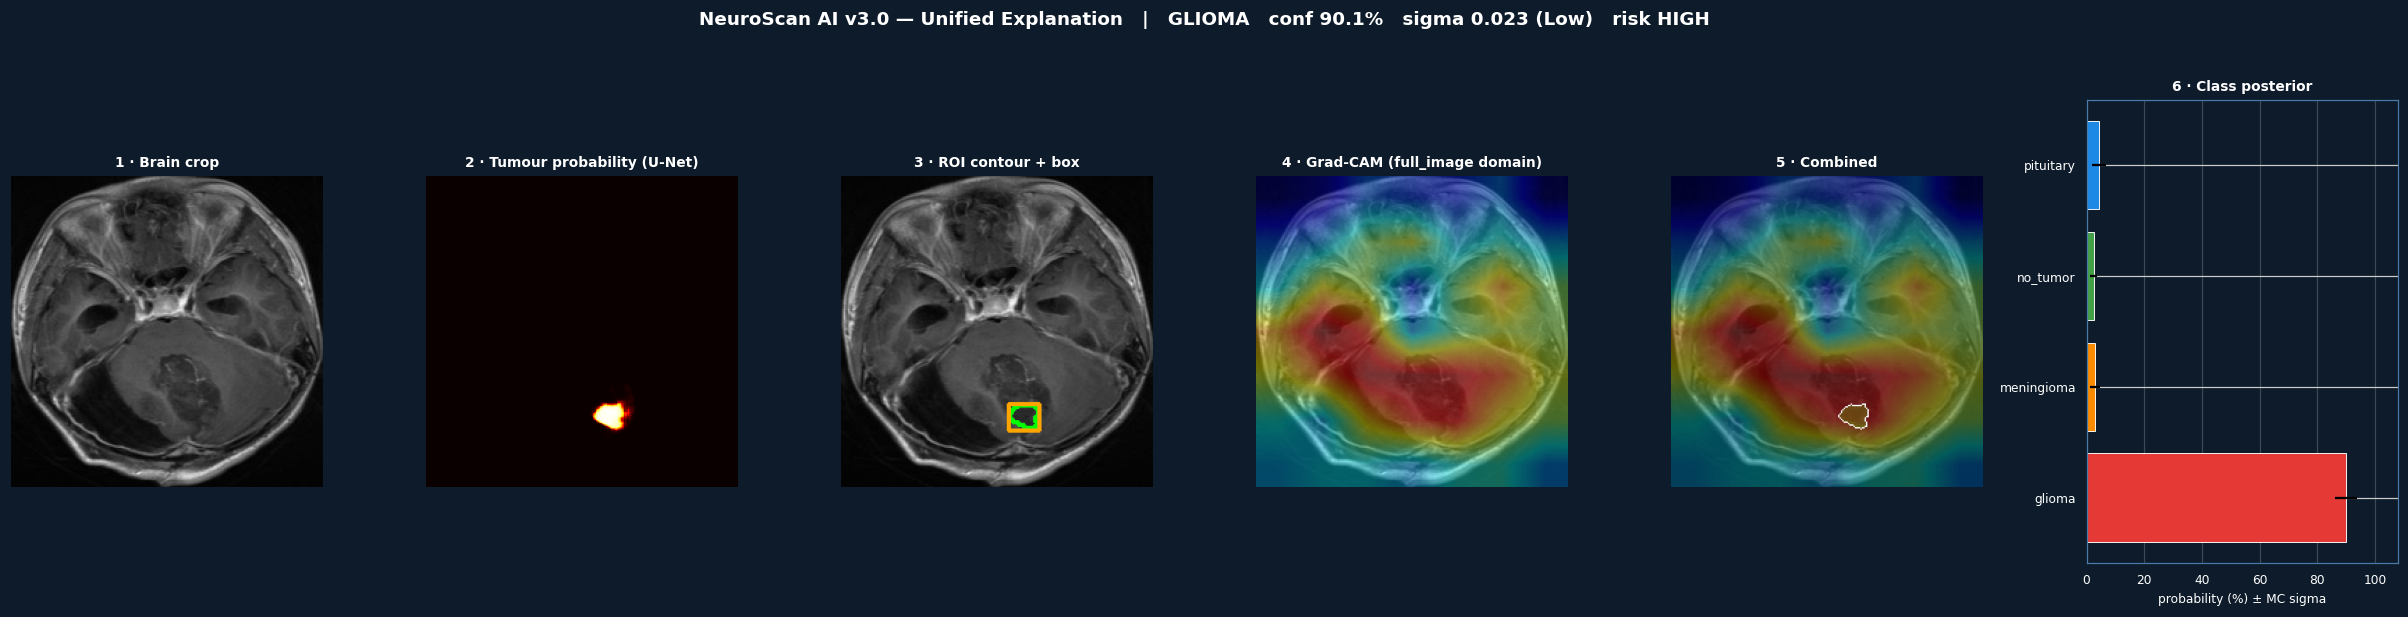

  glioma       pred=glioma       conf= 90.1% sigma=0.0233 area=259px² circ=0.705 Lower-Right


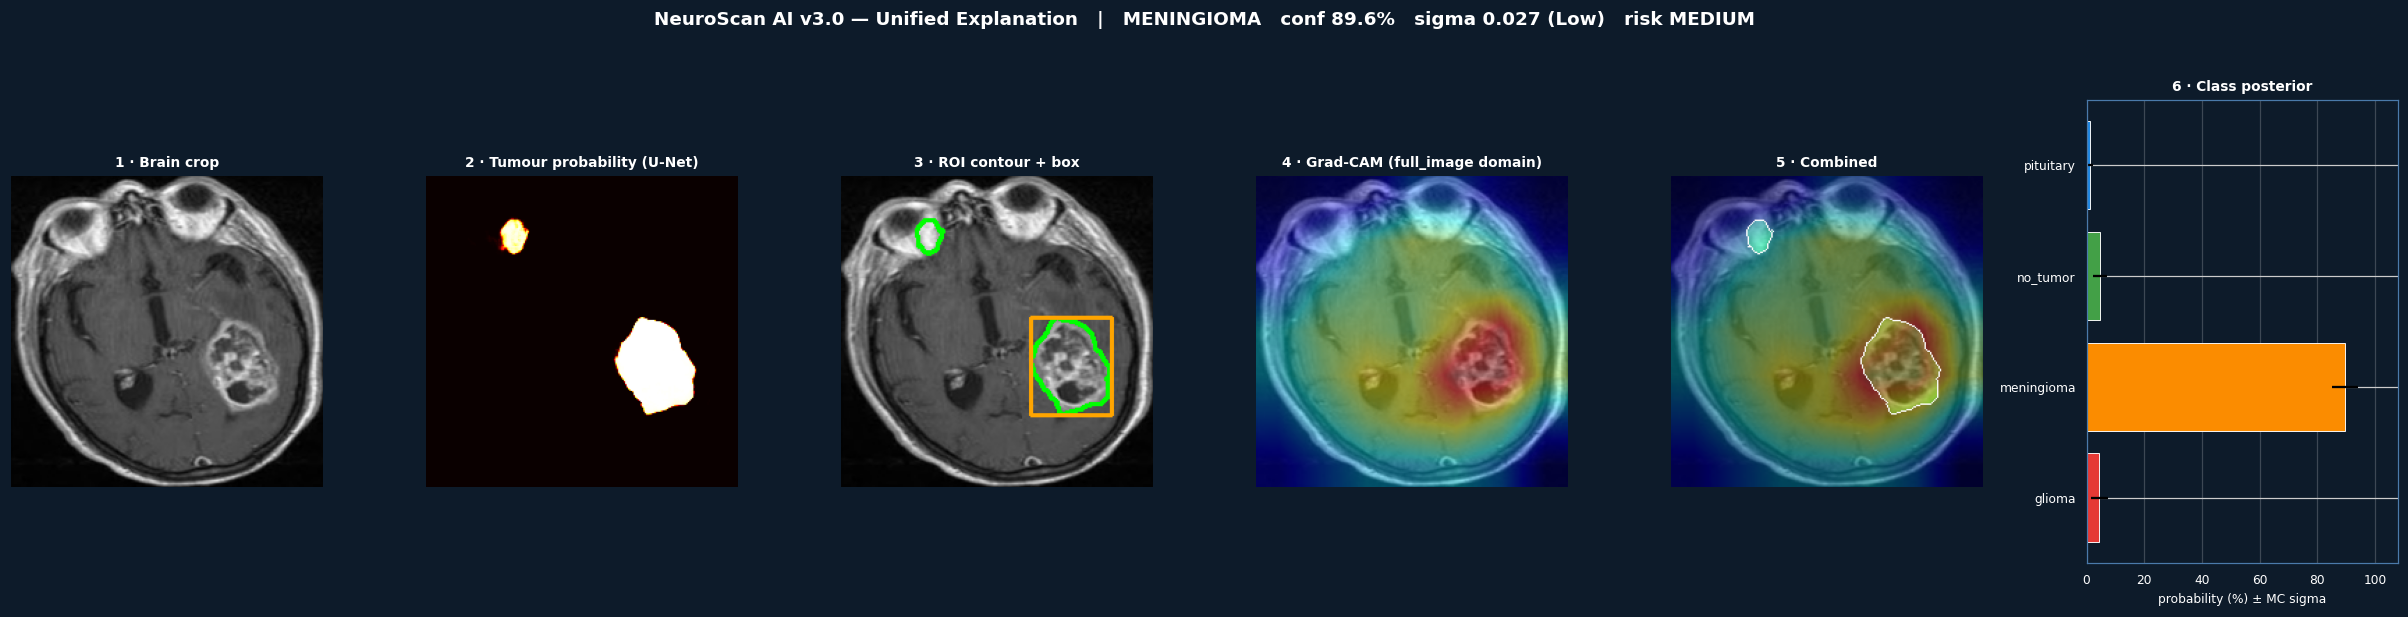

  meningioma   pred=meningioma   conf= 89.6% sigma=0.0268 area=2652px² circ=0.745 Lower-Right


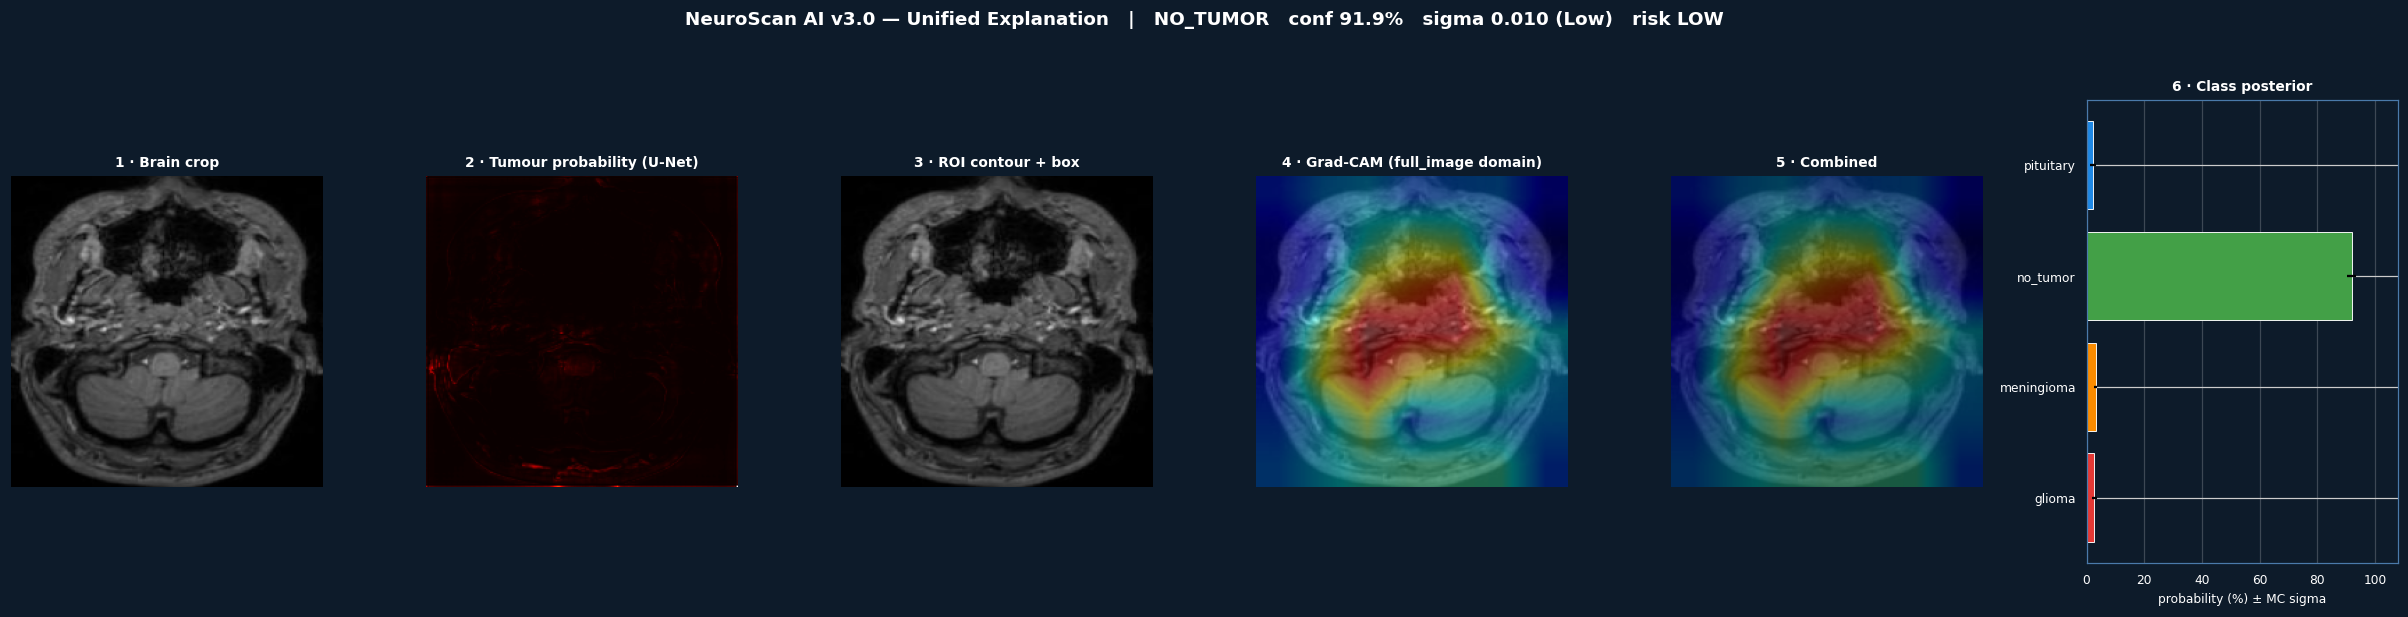

  no_tumor     pred=no_tumor     conf= 91.9% sigma=0.0099 no tumour region segmented


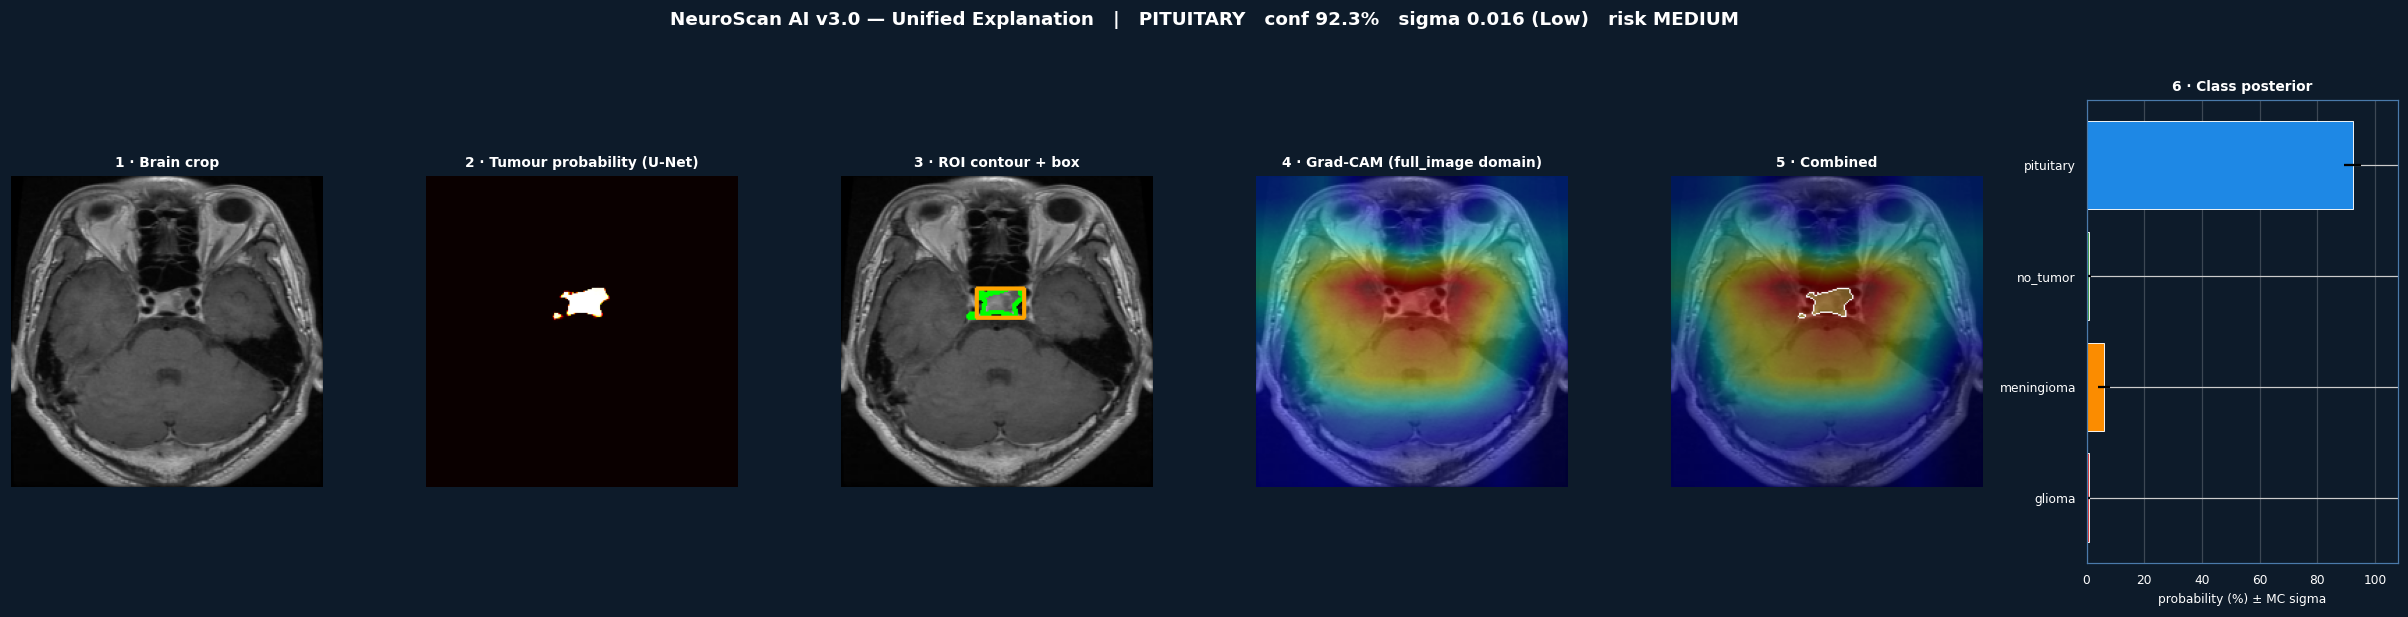

  pituitary    pred=pituitary    conf= 92.3% sigma=0.0158 area=414px² circ=0.472 Upper-Right

4/4 class explanations written and verified (v2 silently produced 1 while reporting 4).


In [16]:
# ═════════════════════════════════════════════════════════════════════════════
#  UNIFIED EXPLAINABILITY — five panels per class
#
#  Two v2 bugs are gone:
#    * the per-class loop had a mis-indented `break`, so it emitted one class
#      and then claimed all four files had been written;
#    * Grad-CAM ran on the full brain crop even when the classifier had been
#      trained on ROI crops. Here the heat map is always computed on the exact
#      tensor the model consumes.
# ═════════════════════════════════════════════════════════════════════════════
RISK_BY_CLASS = {"glioma": "HIGH", "meningioma": "MEDIUM",
                 "pituitary": "MEDIUM", "no_tumor": "LOW"}
RISK_COLOUR = {"HIGH": "#E53935", "MEDIUM": "#FB8C00", "LOW": "#43A047"}


@torch.no_grad()
def predict_mask(img_u8: np.ndarray) -> np.ndarray:
    seg_model.eval()
    logits = seg_model(to_tensor_unit(img_u8)[None].to(device))
    return torch.sigmoid(logits.float()).cpu().numpy()[0, 0]


def tumour_geometry(mask_prob: np.ndarray) -> Optional[dict]:
    binary = (mask_prob > cfg.roi_threshold).astype(np.uint8)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    c = max(contours, key=cv2.contourArea)
    area = float(cv2.contourArea(c))
    perim = float(cv2.arcLength(c, True))
    m = cv2.moments(c)
    cx = int(m["m10"] / m["m00"]) if m["m00"] else 0
    cy = int(m["m01"] / m["m00"]) if m["m00"] else 0
    return {"area_px": area, "perimeter_px": perim, "centroid": (cx, cy),
            "circularity": float(4 * math.pi * area / perim ** 2) if perim > 0 else 0.0,
            "area_fraction": float(binary.mean()),
            "quadrant": f"{'Upper' if cy < S / 2 else 'Lower'}-{'Left' if cx < S / 2 else 'Right'}",
            "contours": contours}


def unified_explanation(result: dict, save_path: Optional[Path] = None) -> dict:
    img = result["image"]
    mask_prob = predict_mask(img)
    geom = tumour_geometry(mask_prob)

    roi_overlay = img.copy()
    if geom is not None:
        cv2.drawContours(roi_overlay, geom["contours"], -1, (0, 255, 0), 2)
        x, y, w, h = cv2.boundingRect(max(geom["contours"], key=cv2.contourArea))
        cv2.rectangle(roi_overlay, (x, y), (x + w, y + h), (255, 165, 0), 2)

    gradcam_panel = result["gradcam_overlay"]
    heat_full = cv2.resize(result["heatmap"], (S, S))
    tint = np.zeros_like(img, dtype=np.float32)
    tint[..., 1] = (mask_prob > cfg.roi_threshold) * 255
    combined = cv2.addWeighted(img.astype(np.float32), 0.70, tint, 0.30, 0).astype(np.uint8)
    combined = cv2.addWeighted(combined, 0.65,
                               overlay_heatmap(img, heat_full, 1.0), 0.35, 0)
    if geom is not None:
        cv2.drawContours(combined, geom["contours"], -1, (255, 255, 255), 1)

    risk = RISK_BY_CLASS[result["prediction"]]
    fig = plt.figure(figsize=(22, 5.4))
    fig.patch.set_facecolor("#0d1b2a")
    fig.suptitle(
        f"{cfg.project} — Unified Explanation   |   {result['prediction'].upper()}   "
        f"conf {result['confidence'] * 100:.1f}%   sigma {result['uncertainty']:.3f} "
        f"({result['uncertainty_level']})   risk {risk}",
        color="white", fontsize=12, fontweight="bold", y=1.03)

    panels = [
        (img, None, "1 · Brain crop"),
        (mask_prob, "hot", "2 · Tumour probability (U-Net)"),
        (roi_overlay, None, "3 · ROI contour + box"),
        (gradcam_panel, None, f"4 · Grad-CAM ({result['input_domain']} domain)"),
        (combined, None, "5 · Combined"),
    ]
    for i, (panel, cmap, title) in enumerate(panels):
        ax = fig.add_subplot(1, 6, i + 1)
        ax.imshow(panel, cmap=cmap)
        ax.set_title(title, color="white", fontsize=9, fontweight="bold")
        ax.axis("off")
        for sp in ax.spines.values():
            sp.set_edgecolor(RISK_COLOUR[risk] if i == 4 else "#4a7aaa")

    ax = fig.add_subplot(1, 6, 6)
    ax.barh(CLASS_NAMES, np.array(result["probabilities"]) * 100,
            xerr=np.array(result["per_class_sigma"]) * 100,
            color=["#E53935", "#FB8C00", "#43A047", "#1E88E5"],
            edgecolor="white", linewidth=0.6)
    ax.set_facecolor("#0d1b2a")
    ax.tick_params(colors="white", labelsize=8)
    ax.set_xlim(0, 108)
    ax.set_xlabel("probability (%) ± MC sigma", color="white", fontsize=8)
    ax.set_title("6 · Class posterior", color="white", fontsize=9, fontweight="bold")
    ax.grid(axis="x", alpha=0.2, color="white")
    for sp in ax.spines.values():
        sp.set_color("#4a7aaa")

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()
    plt.close(fig)

    result = dict(result)
    result.update(mask_prob=mask_prob, geometry=geom, combined=combined, risk=risk)
    return result


# ── One explanation per class. The loop structure is the point. ────────────
XAI_RESULTS: Dict[str, dict] = {}
for class_id, class_name in enumerate(CLASS_NAMES):
    chosen = None
    for rec, pred in zip(test_recs, BEST_ARM["test_preds"]):
        if rec["label"] == class_id and int(pred) == class_id:
            chosen = rec
            break                                  # breaks the INNER loop only
    if chosen is None:
        chosen = next((r for r in test_recs if r["label"] == class_id), None)
    if chosen is None:
        print(f"  {class_name}: no test sample available")
        continue
    out_png = OUT / "xai" / f"unified_{class_name}.png"
    res = unified_explanation(analyse_image(chosen["path"]), save_path=out_png)
    register_artifact(out_png, f"Five-panel unified explanation — {class_name}")
    XAI_RESULTS[class_name] = res
    g = res["geometry"]
    print(f"  {class_name:<12} pred={res['prediction']:<12} conf={res['confidence'] * 100:5.1f}% "
          f"sigma={res['uncertainty']:.4f} "
          + (f"area={g['area_px']:.0f}px² circ={g['circularity']:.3f} {g['quadrant']}"
             if g else "no tumour region segmented"))

assert len(XAI_RESULTS) == len(CLASS_NAMES), \
    f"expected {len(CLASS_NAMES)} explanations, produced {len(XAI_RESULTS)}"
print(f"\n{len(XAI_RESULTS)}/{len(CLASS_NAMES)} class explanations written and verified "
      f"(v2 silently produced 1 while reporting 4).")

## 17 · Clinical report

In [19]:
import sys
!{sys.executable} -m pip install reportlab
# ═════════════════════════════════════════════════════════════════════════════
#  CLINICAL PDF REPORT
#
#  Every number in this report is read from the live metric objects. v2 printed
#  a hard-coded "97.81% test accuracy" and named the wrong source dataset.
#
#  Label keys are normalised with a regex that strips ALL non-letters, so
#  "no_tumor" resolves correctly. v2 used .replace(" ", ""), which does not
#  remove the underscore, so every no_tumor report fell through to
#  risk=UNKNOWN with no interpretation and no recommendation.
# ═════════════════════════════════════════════════════════════════════════════
import re
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                TableStyle, HRFlowable, Image as RLImage)
from reportlab.lib import colors as rl
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib.pagesizes import A4
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY

DARK, MED, BLUE = rl.HexColor("#0d1b2a"), rl.HexColor("#1a3050"), rl.HexColor("#4a7aaa")
LGRAY, MGRAY, BODY = rl.HexColor("#f5f7fa"), rl.HexColor("#e0e8f0"), rl.HexColor("#2a3a4a")
RISK_RL = {"HIGH": rl.HexColor("#E53935"), "MEDIUM": rl.HexColor("#FB8C00"),
           "LOW": rl.HexColor("#43A047")}


def norm_key(label: str) -> str:
    """'no_tumor' -> 'notumor'. Strips every non-letter, not just spaces."""
    return re.sub(r"[^a-z]", "", label.lower())


INTERPRETATION = {
    "glioma": "Imaging features are consistent with glioma, a primary intra-axial tumour of glial "
              "origin. Irregular enhancement, mass effect and perilesional oedema are the features "
              "that typically drive this classification. Urgent neuro-oncology referral and tissue "
              "sampling are the standard next steps.",
    "meningioma": "Imaging features are consistent with meningioma, typically a slow-growing "
                  "extra-axial lesion arising from arachnoid cap cells. A dural tail and homogeneous "
                  "enhancement are characteristic. Neurosurgical consultation is indicated.",
    "notumor": "No imaging features consistent with an intracranial neoplasm were identified in this "
               "slice. Note that a single 2D slice cannot exclude disease elsewhere in the volume. "
               "Follow-up should proceed per the referring clinician's protocol.",
    "pituitary": "Imaging features are consistent with a sellar or parasellar lesion. Endocrine "
                 "evaluation for hormonal hypersecretion and visual field assessment for chiasmal "
                 "compression are indicated.",
}
RECOMMENDATION = {
    "glioma": "Urgent neuro-oncology referral; MR spectroscopy, perfusion imaging and tissue sampling.",
    "meningioma": "Neurosurgical consultation; contrast-enhanced MRI and visual field assessment.",
    "notumor": "Routine monitoring; correlate with clinical presentation and symptoms.",
    "pituitary": "Endocrinology and neurosurgery referral; pituitary hormone panel and visual fields.",
}
assert set(INTERPRETATION) == set(RECOMMENDATION) == {norm_key(c) for c in CLASS_NAMES}, \
    "report dictionaries must cover exactly the configured class set"


CELL_STYLE = ParagraphStyle("Cell", fontName="Helvetica", fontSize=8.5,
                            textColor=BODY, leading=11)


def _wrap(value, width_cm: float):
    """Long strings become Paragraphs so ReportLab wraps instead of clipping."""
    if isinstance(value, str) and len(value) > width_cm * 5.2:
        return Paragraph(value, CELL_STYLE)
    return value


def _table(data, widths, header_fill=MED):
    data = [data[0]] + [[_wrap(v, widths[i] / cm) for i, v in enumerate(row)]
                        for row in data[1:]]
    t = Table(data, colWidths=widths)
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), header_fill),
        ("TEXTCOLOR", (0, 0), (-1, 0), rl.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [LGRAY, rl.white]),
        ("GRID", (0, 0), (-1, -1), 0.5, MGRAY),
        ("FONTSIZE", (0, 0), (-1, -1), 8.5),
        ("TOPPADDING", (0, 0), (-1, -1), 4), ("BOTTOMPADDING", (0, 0), (-1, -1), 4),
        ("LEFTPADDING", (0, 0), (-1, -1), 6),
        ("TEXTCOLOR", (0, 1), (-1, -1), BODY),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
    ]))
    return t


def generate_report(result: dict, output_path: Path) -> Path:
    ss = getSampleStyleSheet()
    title = ParagraphStyle("T", parent=ss["Normal"], fontName="Helvetica-Bold",
                           fontSize=16, textColor=DARK, alignment=TA_CENTER, spaceAfter=6)
    sub = ParagraphStyle("S", parent=ss["Normal"], fontName="Helvetica",
                         fontSize=9, textColor=BLUE, alignment=TA_CENTER, spaceAfter=4)
    h1 = ParagraphStyle("H1", parent=ss["Normal"], fontName="Helvetica-Bold",
                        fontSize=10.5, textColor=DARK, spaceBefore=9, spaceAfter=3)
    body = ParagraphStyle("B", parent=ss["Normal"], fontName="Helvetica", fontSize=8.5,
                          textColor=BODY, leading=12.5, alignment=TA_JUSTIFY, spaceAfter=3)
    small = ParagraphStyle("D", parent=ss["Normal"], fontName="Helvetica-Oblique",
                           fontSize=7.5, textColor=BLUE, leading=10.5, alignment=TA_JUSTIFY)

    key = norm_key(result["prediction"])
    risk = RISK_BY_CLASS[result["prediction"]]
    now = datetime.datetime.now()
    rid = "NS3-" + now.strftime("%Y%m%d-%H%M%S")
    e = []

    e.append(Paragraph(f"{cfg.project} — Clinical Imaging Report", title))
    e.append(Paragraph("AI-assisted neuro-radiological screening (research use only)", sub))
    e.append(HRFlowable(width="100%", thickness=2, color=MED, spaceAfter=7))

    e.append(_table([
        ["Report ID", rid, "Generated", now.strftime("%d %b %Y %H:%M")],
        ["Source", Path(result["source"]).name, "Input domain", result["input_domain"]],
        ["Deployed arm", BEST_ARM["arm"], "Backbone", "EfficientNet-B0"],
    ], [2.4 * cm, 6.4 * cm, 2.4 * cm, 5.8 * cm]))
    e.append(Spacer(1, 8))

    e.append(Paragraph("PRIMARY AI IMPRESSION", h1))
    diag = _table([
        ["AI impression", result["prediction"].upper()],
        ["Ensemble confidence", f"{result['confidence'] * 100:.2f}%"],
        ["Risk stratum", risk],
        ["Predictive uncertainty", f"sigma = {result['uncertainty']:.4f} ({result['uncertainty_level']})"],
        ["Branch consensus", f"{result['consensus_ratio'] * 100:.0f}% of the three branches agree"],
    ], [4.6 * cm, 12.4 * cm])
    diag.setStyle(TableStyle([("TEXTCOLOR", (1, 2), (1, 2), RISK_RL[risk]),
                              ("FONTNAME", (1, 0), (1, 0), "Helvetica-Bold"),
                              ("FONTSIZE", (1, 0), (1, 0), 11)]))
    e.append(diag)
    e.append(Spacer(1, 8))

    e.append(Paragraph("CLASS POSTERIOR", h1))
    rows = [["Class", "Ensemble", "Standard", "MC dropout", "TTA", "MC sigma", ""]]
    for i, c in enumerate(CLASS_NAMES):
        rows.append([c, f"{result['probabilities'][i] * 100:.2f}%",
                     f"{result['std_probs'][i] * 100:.2f}%",
                     f"{result['mc_probs'][i] * 100:.2f}%",
                     f"{result['tta_probs'][i] * 100:.2f}%",
                     f"{result['per_class_sigma'][i]:.4f}",
                     "SELECTED" if i == result["class_id"] else ""])
    e.append(_table(rows, [3.2 * cm, 2.4 * cm, 2.4 * cm, 2.4 * cm, 2.2 * cm, 2.2 * cm, 2.2 * cm]))
    e.append(Spacer(1, 4))
    w = result["ensemble_weights"]
    e.append(Paragraph(
        f"Fusion weights {w[0]:.2f} / {w[1]:.2f} / {w[2]:.2f} (standard / MC dropout / TTA) were "
        f"selected by grid search on the validation split; the held-out test split took no part "
        f"in choosing them.", small))
    e.append(Spacer(1, 8))

    if result.get("geometry"):
        g = result["geometry"]
        e.append(Paragraph("LESION GEOMETRY (Attention U-Net)", h1))
        e.append(_table([
            ["Area", f"{g['area_px']:.0f} px² ({g['area_fraction'] * 100:.2f}% of the crop)",
             "Circularity", f"{g['circularity']:.3f}"],
            ["Centroid", f"({g['centroid'][0]}, {g['centroid'][1]})",
             "Quadrant", g["quadrant"]],
        ], [2.6 * cm, 7.0 * cm, 2.6 * cm, 4.8 * cm]))
        e.append(Spacer(1, 8))

    e.append(Paragraph("INTERPRETATION", h1))
    e.append(Paragraph(INTERPRETATION[key], body))
    e.append(Paragraph(f"<b>Recommendation:</b> {RECOMMENDATION[key]}", body))
    e.append(Spacer(1, 8))

    e.append(Paragraph("MODEL PROVENANCE (measured, not asserted)", h1))
    seg_line = (f"Attention U-Net on {SEG_RESULTS['mask_supervision']} masks — "
                f"test Dice {SEG_RESULTS['test_dice']:.4f}, IoU {SEG_RESULTS['test_iou']:.4f}")
    e.append(_table([
        ["Dataset", f"{cfg.dataset_name} — {len(train_recs)} train / {len(val_recs)} val / "
                    f"{len(test_recs)} held-out test"],
        ["Test split", "Official BRISC2025 test folder, untouched during training"],
        ["Segmentation", seg_line],
        ["Deployed classifier", f"{BEST_ARM['arm']} — test accuracy "
                                f"{SINGLE_METRICS['accuracy'] * 100:.2f}%, macro F1 "
                                f"{SINGLE_METRICS['macro_f1'] * 100:.2f}%"],
        ["With ensemble", f"test accuracy {ENSEMBLE_METRICS['accuracy'] * 100:.2f}%, macro F1 "
                          f"{ENSEMBLE_METRICS['macro_f1'] * 100:.2f}%, "
                          f"kappa {ENSEMBLE_METRICS['cohen_kappa']:.4f}"],
        ["Controlled contrast", f"full-image arm macro F1 "
                                f"{ARMS['full_image']['test_metrics']['macro_f1'] * 100:.2f}% vs "
                                f"ROI arm {ARMS['roi_guided']['test_metrics']['macro_f1'] * 100:.2f}%; "
                                f"McNemar p = {mcnemar['p_value']:.4f}"],
        ["Explainability", "Grad-CAM on the last backbone convolution, computed on the same "
                           "input domain the model was trained on"],
        ["Uncertainty", f"MC dropout, {cfg.mc_samples} stochastic passes (BatchNorm frozen)"],
    ], [4.0 * cm, 13.0 * cm], header_fill=DARK))
    e.append(Spacer(1, 10))

    e.append(HRFlowable(width="100%", thickness=2, color=MED, spaceAfter=5))
    e.append(Paragraph(
        "IMPORTANT: this is an experimental research system. This report is not a medical "
        "diagnosis, has not been reviewed by a licensed clinician, and must not be used to "
        "direct patient care. Model outputs are derived from a single 2D slice and must be "
        "correlated with the full study, clinical history and expert radiological "
        "interpretation. The authors accept no liability for decisions based on this output.",
        small))

    SimpleDocTemplate(str(output_path), pagesize=A4, topMargin=1.5 * cm,
                      bottomMargin=1.5 * cm, leftMargin=2.0 * cm,
                      rightMargin=2.0 * cm).build(e)
    return output_path


REPORTS = {}
for class_name, res in XAI_RESULTS.items():
    p = generate_report(res, OUT / "reports" / f"report_{class_name}.pdf")
    register_artifact(p, f"Clinical PDF report — {class_name}")
    REPORTS[class_name] = p
    print(f"  {class_name:<12} -> {p}  (risk {res['risk']}, "
          f"interpretation resolved: {norm_key(res['prediction']) in INTERPRETATION})")

_nt = XAI_RESULTS.get("no_tumor")
if _nt is not None:
    assert RISK_BY_CLASS[_nt["prediction"]] != "UNKNOWN"
    print(f"\n  no_tumor report resolves to risk "
          f"'{RISK_BY_CLASS[_nt['prediction']]}' with a real interpretation — "
          f"this is the case v2 silently degraded to UNKNOWN.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.7 MB/s eta 0:00:00
  glioma       -> artifacts/reports/report_glioma.pdf  (risk HIGH, interpretation resolved: True)
  meningioma   -> artifacts/reports/report_meningioma.pdf  (risk MEDIUM, interpretation resolved: True)
  no_tumor     -> artifacts/reports/report_no_tumor.pdf  (risk LOW, interpretation resolved: True)
  pituitary    -> artifacts/reports/report_pituitary.pdf  (risk MEDIUM, interpretation resolved: True)

  no_tumor report resolves to risk 'LOW' with a real interpretation — this is the case v2 silently degraded to UNKNOWN.


## 18 · Figures

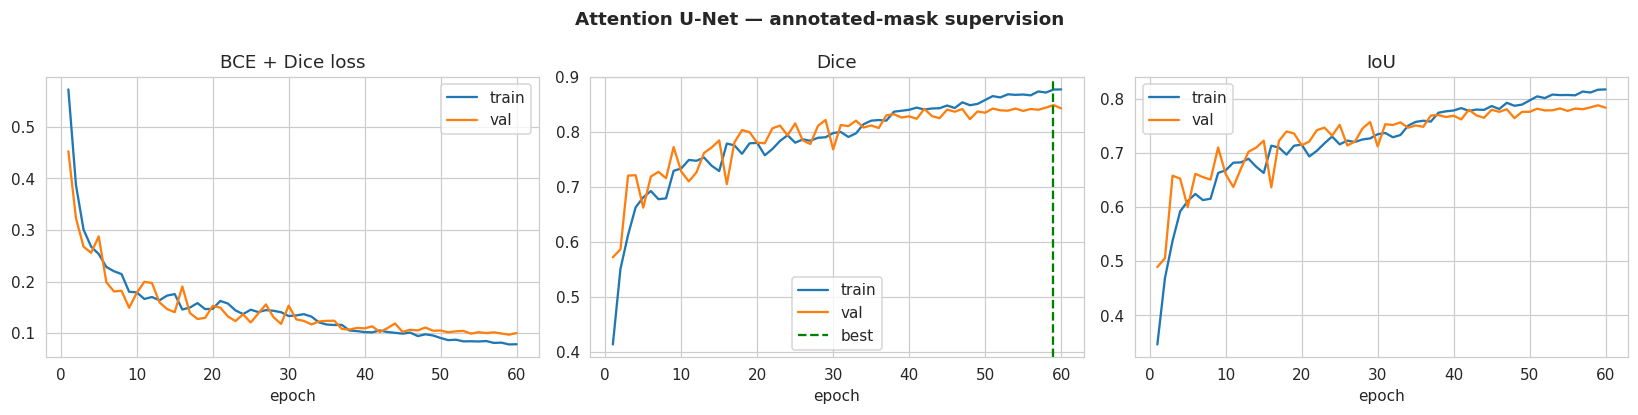

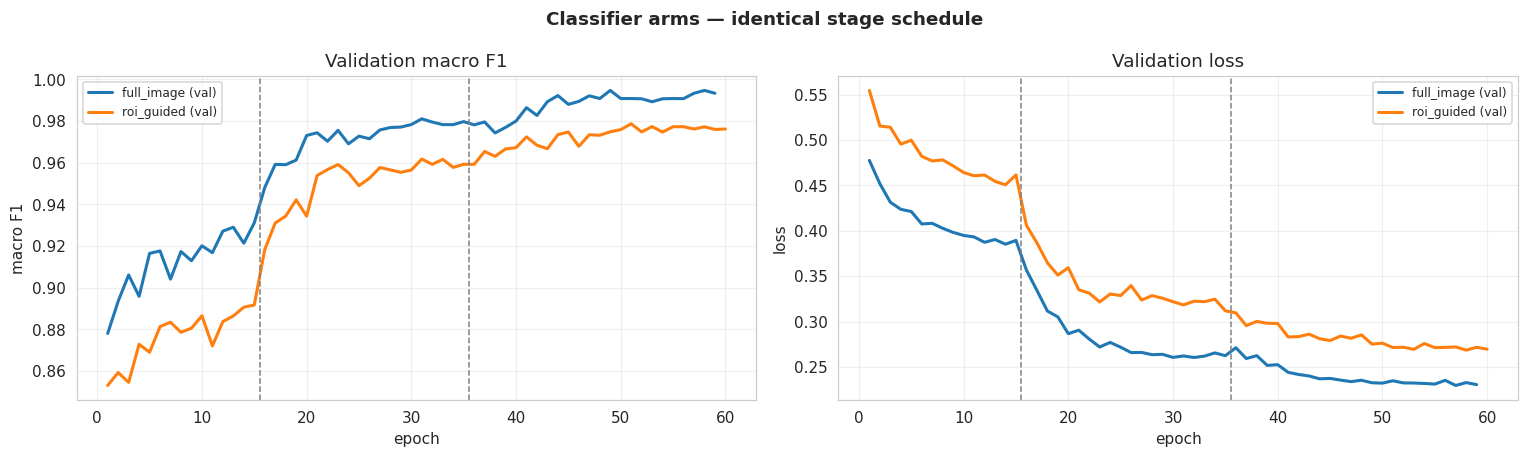

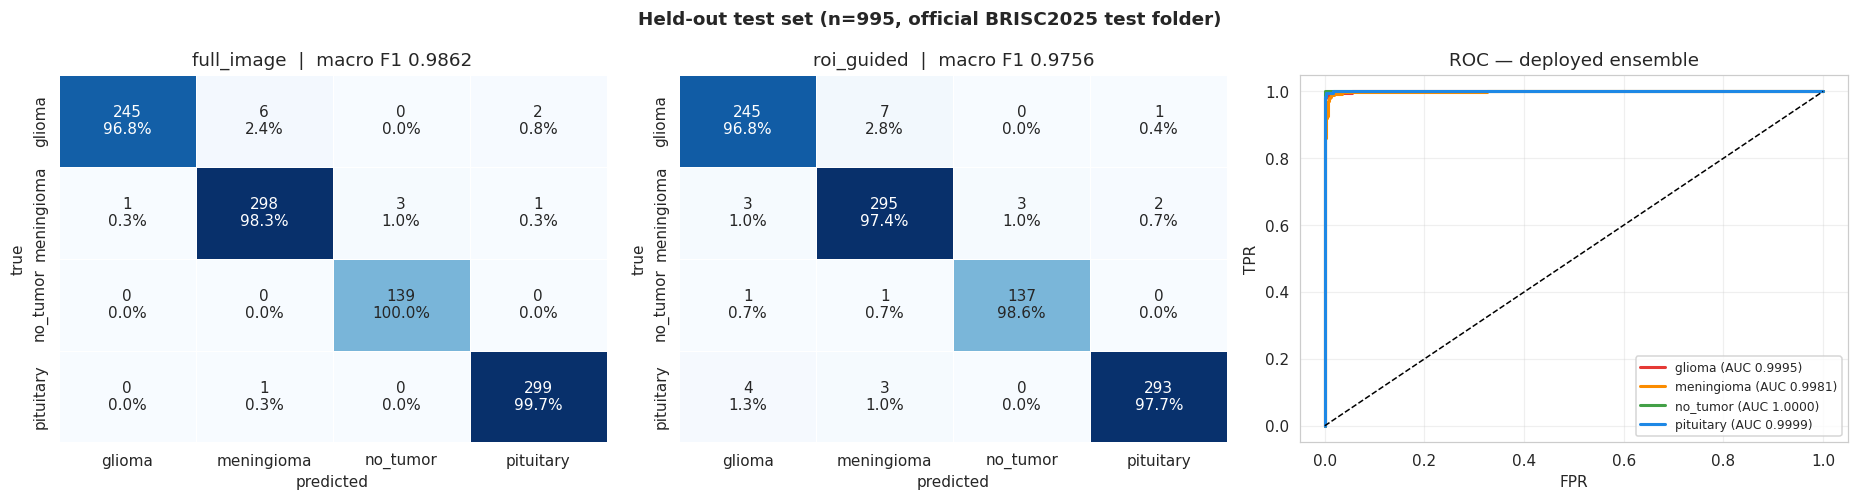

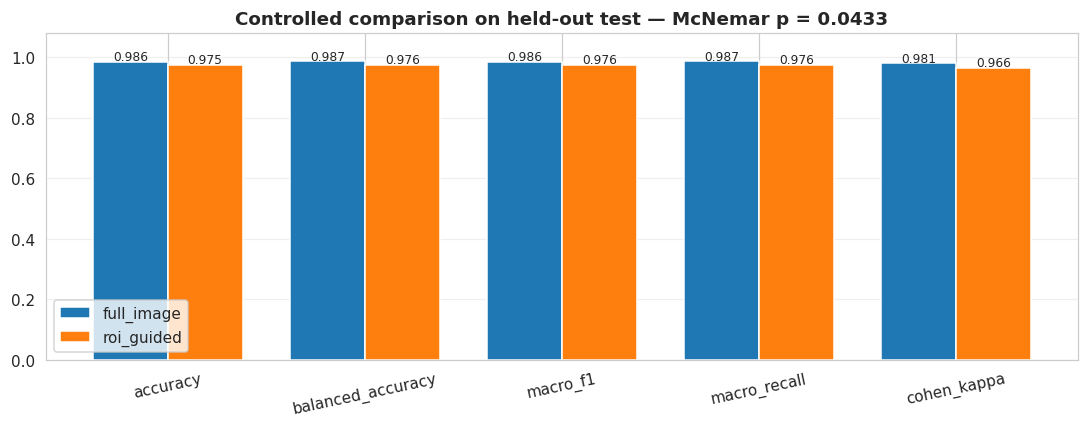

4 figures written to artifacts/figures


In [20]:
# ═════════════════════════════════════════════════════════════════════════════
#  FIGURES — one function, called once per artefact. No duplicated definitions.
# ═════════════════════════════════════════════════════════════════════════════
def plot_segmentation_curves(path: Path):
    h = seg_history
    ep = h["epoch"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    fig.suptitle("Attention U-Net — annotated-mask supervision", fontweight="bold")
    ax[0].plot(ep, h["loss"], label="train"); ax[0].plot(ep, h["val_loss"], label="val")
    ax[0].set_title("BCE + Dice loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(ep, h["dice"], label="train"); ax[1].plot(ep, h["val_dice"], label="val")
    ax[1].axvline(SEG_RESULTS["best_epoch"], ls="--", c="green", label="best")
    ax[1].set_title("Dice"); ax[1].set_xlabel("epoch"); ax[1].legend()
    ax[2].plot(ep, h["iou"], label="train"); ax[2].plot(ep, h["val_iou"], label="val")
    ax[2].set_title("IoU"); ax[2].set_xlabel("epoch"); ax[2].legend()
    plt.tight_layout(); fig.savefig(path, dpi=150); plt.show(); plt.close(fig)


def plot_arm_curves(path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    fig.suptitle("Classifier arms — identical stage schedule", fontweight="bold")
    for name, entry in ARMS.items():
        h = entry["history"]
        axes[0].plot(h["epoch"], h["val_macro_f1"], lw=2, label=f"{name} (val)")
        axes[1].plot(h["epoch"], h["val_loss"], lw=2, label=f"{name} (val)")
    boundaries, seen = [], 0
    for stage in cfg.stage_names[:-1]:
        seen += sum(1 for s in ARMS["roi_guided"]["history"]["stage"] if s == stage)
        boundaries.append(seen)
    for ax, title, ylab in ((axes[0], "Validation macro F1", "macro F1"),
                            (axes[1], "Validation loss", "loss")):
        for b in boundaries:
            ax.axvline(b + 0.5, color="grey", ls="--", lw=1)
        ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel(ylab)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); fig.savefig(path, dpi=150); plt.show(); plt.close(fig)


def plot_test_panels(path: Path):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
    fig.suptitle(f"Held-out test set (n={len(test_recs)}, official BRISC2025 test folder)",
                 fontweight="bold")
    for ax, (name, entry) in zip(axes[:2], ARMS.items()):
        cm = confusion_matrix(entry["test_targets"], entry["test_preds"])
        norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
        annot = np.array([[f"{cm[i, j]}\n{norm[i, j] * 100:.1f}%"
                           for j in range(cm.shape[1])] for i in range(cm.shape[0])])
        sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=False,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, linewidths=0.5)
        ax.set_title(f"{name}  |  macro F1 {entry['test_metrics']['macro_f1']:.4f}")
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax = axes[2]
    binar = label_binarize(test_y, classes=list(range(cfg.num_classes)))
    for i, (c, col) in enumerate(zip(CLASS_NAMES, ["#E53935", "#FB8C00", "#43A047", "#1E88E5"])):
        if binar[:, i].sum() in (0, len(test_y)):
            continue
        fpr, tpr, _ = roc_curve(binar[:, i], test_ens[:, i])
        ax.plot(fpr, tpr, color=col, lw=2, label=f"{c} (AUC {auc(fpr, tpr):.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("ROC — deployed ensemble"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); fig.savefig(path, dpi=150); plt.show(); plt.close(fig)


def plot_comparison(path: Path):
    keys = ["accuracy", "balanced_accuracy", "macro_f1", "macro_recall", "cohen_kappa"]
    x = np.arange(len(keys)); w = 0.38
    fig, ax = plt.subplots(figsize=(10, 4))
    for off, (name, entry) in zip((-w / 2, w / 2), ARMS.items()):
        vals = [entry["test_metrics"][k] for k in keys]
        bars = ax.bar(x + off, vals, w, label=name)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                    ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(keys, rotation=12)
    ax.set_ylim(0, 1.08); ax.legend(); ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"Controlled comparison on held-out test — McNemar p = {mcnemar['p_value']:.4f}",
                 fontweight="bold")
    plt.tight_layout(); fig.savefig(path, dpi=150); plt.show(); plt.close(fig)


for fn, fname, desc in (
    (plot_segmentation_curves, "segmentation_curves.png", "Attention U-Net training curves"),
    (plot_arm_curves, "arm_curves.png", "Per-arm validation curves with stage boundaries"),
    (plot_test_panels, "test_panels.png", "Confusion matrices and ROC on the held-out test set"),
    (plot_comparison, "arm_comparison.png", "Controlled arm comparison"),
):
    p = OUT / "figures" / fname
    fn(p)
    register_artifact(p, desc)

print(f"{len([k for k in ARTIFACTS if 'figures' in k])} figures written to {OUT / 'figures'}")

## 19 · Manifest, release package and summary

In [21]:
# ═════════════════════════════════════════════════════════════════════════════
#  MANIFEST, RELEASE PACKAGE AND FINAL SUMMARY
#
#  The manifest lists only files that were actually registered as they were
#  written, so it can never advertise an artefact the run did not produce.
#  The README is generated from live metrics and describes THIS project.
# ═════════════════════════════════════════════════════════════════════════════
import zipfile

RUN_SUMMARY = {
    "project": cfg.project,
    "generated": datetime.datetime.now().isoformat(timespec="seconds"),
    "dataset": cfg.dataset_name,
    "dataset_root": str(DATA_ROOT),
    "splits": {k: len(v) for k, v in SPLITS.items()},
    "deduplication": dedup_stats,
    "segmentation": SEG_RESULTS,
    "roi": ROI_STATS,
    "arms": {n: e["test_metrics"] for n, e in ARMS.items()},
    "stages": {n: e["stages"] for n, e in ARMS.items()},
    "mcnemar": mcnemar,
    "selected_arm": BEST_ARM["arm"],
    "ensemble_weights": {"standard": ENS_W[0], "mc_dropout": ENS_W[1], "tta": ENS_W[2]},
    "ensemble_test_metrics": ENSEMBLE_METRICS,
    "single_pass_test_metrics": SINGLE_METRICS,
    "config": asdict(cfg),
    "environment": {"python": platform.python_version(), "torch": torch.__version__,
                    "cuda": torch.version.cuda, "device": str(device), "amp": USE_AMP},
}
summary_path = OUT / "metrics" / "run_summary.json"
summary_path.write_text(json.dumps(RUN_SUMMARY, indent=2, default=str))
register_artifact(summary_path, "Complete machine-readable run summary")


def build_readme() -> str:
    ctrl_f1 = ARMS["full_image"]["test_metrics"]["macro_f1"]
    roi_f1 = ARMS["roi_guided"]["test_metrics"]["macro_f1"]
    sig = "significant" if mcnemar["p_value"] < 0.05 else "not significant"
    lines = [
        f"# {cfg.project} — Brain MRI Tumour Segmentation and Classification",
        "",
        f"Generated {RUN_SUMMARY['generated']} · dataset: {cfg.dataset_name}",
        "",
        "## Design",
        "",
        "| Component | Detail |",
        "|---|---|",
        "| Segmenter | Attention U-Net (5-level encoder, attention gate on every skip) |",
        f"| Segmentation supervision | {SEG_RESULTS['mask_supervision']} masks shipped with the dataset |",
        "| Classifier | EfficientNet-B0 + Linear-BN-ReLU-Dropout head |",
        "| Fine-tuning | 3 stages (head → top-20 → top-50 non-BN modules), cosine LR, real gradient clipping |",
        f"| Evaluation | Official held-out test folder, n={len(test_recs)}, untouched during training |",
        f"| Uncertainty | MC dropout, {cfg.mc_samples} passes, BatchNorm frozen |",
        f"| Robustness | Deterministic TTA bank, {cfg.tta_steps} transforms |",
        f"| Fusion | Weights fitted on validation: {ENS_W[0]:.2f}/{ENS_W[1]:.2f}/{ENS_W[2]:.2f} |",
        "",
        "## Segmentation results",
        "",
        "| Metric | Validation | Held-out test |",
        "|---|---|---|",
        f"| Dice | {SEG_RESULTS['val_dice']:.4f} | {SEG_RESULTS['test_dice']:.4f} |",
        f"| IoU | {SEG_RESULTS['val_iou']:.4f} | {SEG_RESULTS['test_iou']:.4f} |",
        "",
        "## Controlled classification comparison",
        "",
        "Both arms share one architecture, seed, schedule and monitor. The only",
        "difference is the input crop, so the delta is attributable to ROI guidance.",
        "",
        "| Metric | full_image (control) | roi_guided | Delta |",
        "|---|---|---|---|",
    ]
    for k in ("accuracy", "balanced_accuracy", "macro_f1", "macro_recall", "cohen_kappa"):
        a = ARMS["full_image"]["test_metrics"][k]
        b = ARMS["roi_guided"]["test_metrics"][k]
        lines.append(f"| {k} | {a:.4f} | {b:.4f} | {b - a:+.4f} |")
    lines += [
        "",
        f"McNemar exact test on paired test items: {mcnemar['discordant']} discordant pairs, "
        f"p = {mcnemar['p_value']:.4f} — the difference is **{sig}** at alpha = 0.05.",
        "",
        f"Deployed arm: **{BEST_ARM['arm']}**. With the fitted ensemble the held-out test "
        f"accuracy is {ENSEMBLE_METRICS['accuracy'] * 100:.2f}% and macro F1 is "
        f"{ENSEMBLE_METRICS['macro_f1'] * 100:.2f}%.",
        "",
        "## Reproducing",
        "",
        f"Seed {cfg.seed}, deterministic cuDNN. Run the notebook top to bottom; every",
        "hyperparameter lives in the CFG dataclass in the configuration cell.",
        "",
        "## Intended use",
        "",
        "Research and benchmarking only. Not a medical device and not validated for",
        "clinical use. Outputs derive from single 2D slices.",
        "",
        "## Artefacts",
        "",
    ]
    for p, d in sorted(ARTIFACTS.items()):
        lines.append(f"- `{p}` — {d}")
    return "\n".join(lines) + "\n"


readme_path = OUT / "README.md"
readme_path.write_text(build_readme())
register_artifact(readme_path, "Generated README describing this run")

manifest_path = OUT / "manifest.json"
manifest_path.write_text(json.dumps(
    {"generated": RUN_SUMMARY["generated"],
     "files": [{"path": p, "description": d, "bytes": Path(p).stat().st_size}
               for p, d in sorted(ARTIFACTS.items()) if Path(p).exists()]},
    indent=2))
register_artifact(manifest_path, "Artefact manifest")

release_path = OUT / f"neuroscan_v3_release_{datetime.datetime.now():%Y%m%d_%H%M%S}.zip"
with zipfile.ZipFile(release_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(ARTIFACTS):
        fp = Path(p)
        if fp.exists() and fp.resolve() != release_path.resolve():
            z.write(fp, fp.relative_to(OUT) if OUT in fp.parents or fp.parent == OUT else fp.name)

print(f"Release package: {release_path}  ({release_path.stat().st_size / 1024:.0f} KB)")
print(f"Manifest lists {len(ARTIFACTS)} files, every one of them verified on disk.\n")

# ── Final summary, generated from the same objects the report reads ────────
bar = "=" * 78
print(bar)
print(f"  {cfg.project} — RUN SUMMARY".center(78))
print(bar)
print(f"\nDATA")
print(f"  source            : {cfg.dataset_name}")
print(f"  splits            : train {len(train_recs)} | val {len(val_recs)} | "
      f"test {len(test_recs)} (official held-out folder)")
print(f"  duplicates removed: {dedup_stats['duplicate']} "
      f"({dedup_stats['cross_split_duplicate']} of them cross-split)")
print(f"\nSEGMENTATION  (supervision: {SEG_RESULTS['mask_supervision']} masks)")
print(f"  best epoch        : {SEG_RESULTS['best_epoch']}")
print(f"  val  Dice / IoU   : {SEG_RESULTS['val_dice']:.4f} / {SEG_RESULTS['val_iou']:.4f}")
print(f"  test Dice / IoU   : {SEG_RESULTS['test_dice']:.4f} / {SEG_RESULTS['test_iou']:.4f}")
print(f"  ROI fallback rate : {ROI_STATS['fallback_rate'] * 100:.1f}%")
print(f"\nCLASSIFICATION  (identical schedule in both arms)")
for name, entry in ARMS.items():
    m = entry["test_metrics"]
    tp = entry["stages"][-1]["trainable_params"]
    print(f"  {name:<12}: acc {m['accuracy']:.4f}  macroF1 {m['macro_f1']:.4f}  "
          f"kappa {m['cohen_kappa']:.4f}  ({tp:,} trainable params at stage C)")
print(f"  McNemar p-value   : {mcnemar['p_value']:.4f} "
      f"({'significant' if mcnemar['p_value'] < 0.05 else 'not significant'} at 0.05)")
print(f"\nDEPLOYED  : {BEST_ARM['arm']}")
print(f"  ensemble weights  : std {ENS_W[0]:.2f} | mc {ENS_W[1]:.2f} | tta {ENS_W[2]:.2f} "
      f"(fitted on validation)")
print(f"  single pass       : acc {SINGLE_METRICS['accuracy']:.4f}  macroF1 {SINGLE_METRICS['macro_f1']:.4f}")
print(f"  with ensemble     : acc {ENSEMBLE_METRICS['accuracy']:.4f}  macroF1 {ENSEMBLE_METRICS['macro_f1']:.4f}")
print(f"\nEXPLAINABILITY")
print(f"  Grad-CAM domain   : {BEST_ARM['arm']} inputs (matches training)")
print(f"  class explanations: {len(XAI_RESULTS)}/{len(CLASS_NAMES)} written and asserted")
print(f"  PDF reports       : {len(REPORTS)}")
print(f"\nARTEFACTS : {len(ARTIFACTS)} files in {OUT.resolve()}")
print(f"\n{bar}")
print("  Every number above was read from a live object. Nothing is hard-coded.".center(78))
print(bar)

Release package: artifacts/neuroscan_v3_release_20260913_093858.zip  (159280 KB)
Manifest lists 27 files, every one of them verified on disk.

                        NeuroScan AI v3.0 — RUN SUMMARY                       

DATA
  source            : BRISC2025 (briscdataset/brisc2025)
  splits            : train 4211 | val 744 | test 995 (official held-out folder)
  duplicates removed: 50 (9 of them cross-split)

SEGMENTATION  (supervision: annotated masks)
  best epoch        : 59
  val  Dice / IoU   : 0.8493 / 0.7884
  test Dice / IoU   : 0.8400 / 0.7756
  ROI fallback rate : 30.3%

CLASSIFICATION  (identical schedule in both arms)
  full_image  : acc 0.9859  macroF1 0.9862  kappa 0.9808  (4,157,780 trainable params at stage C)
  roi_guided  : acc 0.9749  macroF1 0.9756  kappa 0.9657  (4,157,780 trainable params at stage C)
  McNemar p-value   : 0.0433 (significant at 0.05)

DEPLOYED  : full_image
  ensemble weights  : std 0.00 | mc 0.75 | tta 0.25 (fitted on validation)
  single pass

## 20 · What to do with this for the paper

The comparison this notebook runs is the one a reviewer will ask for, but a single
controlled run is a starting point, not a result. Three things are worth adding before
submission:

1. **Repeat both arms across several seeds** and report mean ± standard deviation.
   A single seed cannot distinguish a real 1-point gain from run-to-run noise, and the
   McNemar test above addresses only sampling variation in the test set, not variation
   in training.
2. **Report the segmentation result on its own terms.** Now that supervision comes from
   the dataset's expert masks, Dice and IoU on the held-out folder are directly
   comparable to the BRISC2025 baselines — cite them side by side.
3. **State the ROI fallback rate.** Every `no_tumor` image and any tumour image whose
   predicted region is too small falls back to the full frame, so the ROI arm is a hybrid
   in practice. The rate is printed in Phase 2 and stored in `run_summary.json`.

If the ROI arm does not beat the control once seeds are averaged, that is a finding
worth reporting rather than a problem to engineer around — it would say the classifier
already attends to the lesion without being cropped to it, which the Grad-CAM figures
can support directly.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After mounting your Google Drive, I will move the `neuroscan_v3_release_...zip` file into a dedicated folder in your Google Drive and then extract its contents. You can change the `google_drive_path` variable if you prefer a different location.

In [23]:
import shutil

google_drive_path = '/content/drive/MyDrive/neuroscan_v3_artifacts'

# Create the target directory in Google Drive if it doesn't exist
!mkdir -p "{google_drive_path}"

# Move the release zip file to Google Drive
shutil.move(str(release_path), google_drive_path)

# Unzip the contents in Google Drive
zip_file_name = release_path.name
zip_file_in_drive = f"{google_drive_path}/{zip_file_name}"

print(f"Moving '{zip_file_name}' to '{google_drive_path}' and unzipping...")
!unzip -q "{zip_file_in_drive}" -d "{google_drive_path}"

print(f"Artifacts saved and unzipped in: {google_drive_path}")

Moving 'neuroscan_v3_release_20260913_093858.zip' to '/content/drive/MyDrive/neuroscan_v3_artifacts' and unzipping...
Artifacts saved and unzipped in: /content/drive/MyDrive/neuroscan_v3_artifacts
